In [2]:
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

#sns.set()
#sns.set_style('darkgrid')
sns.set_theme()
pd.set_option('display.max_colwidth',3000)
pd.set_option('display.max_rows', None)

C:\Users\augustocba\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
df_jurisdicionados        = pd.read_excel('../_dados/jurisdicionados.xlsx').set_index('orgao')
df_respostas_questionario = pd.read_excel('dados/resposta_questionario_setic.xlsx').set_index('attribute_1')
df_resultado_igovti       = pd.read_excel('dados/resultado_igovti.xlsx').set_index('attribute_1')
df_resultado_igovti       = df_resultado_igovti.join(df_jurisdicionados)

# Conjunto de órgãos que serão removidos para o cálculo das médias setoriais (pares) e geral
# Esses órgão serão removidos pois apresentam mais de 25% de suas respostas marcadas como 'Não se aplica'
orgaos_outliers = ['CASERJ', 'GVG', 'IASERJ', 'SEIC', 'SEAS', 'SETD']
df_resultado_igovti['r4nk'] = df_resultado_igovti.loc[~df_resultado_igovti.index.isin(orgaos_outliers)]['iGovTI'].rank(ascending=False)

df_resultado_igovti['outliers']       = df_resultado_igovti.index.isin(orgaos_outliers)
df_respostas_questionario['outliers'] = df_respostas_questionario.index.isin(orgaos_outliers)

C:\Users\augustocba\AppData\Local\Temp\ipykernel_11184\1451936093.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_respostas_questionario['outliers'] = df_respostas_questionario.index.isin(orgaos_outliers)


# Análises relativas à Seção do SETIC

In [4]:
df_secao_setic = df_respostas_questionario.filter(regex='^q10')

### 1011. - A organização possui Setor de TI próprio

In [6]:
df_secao_setic['q1011'].value_counts()

Sim    65
Não     8
Name: q1011, dtype: int64

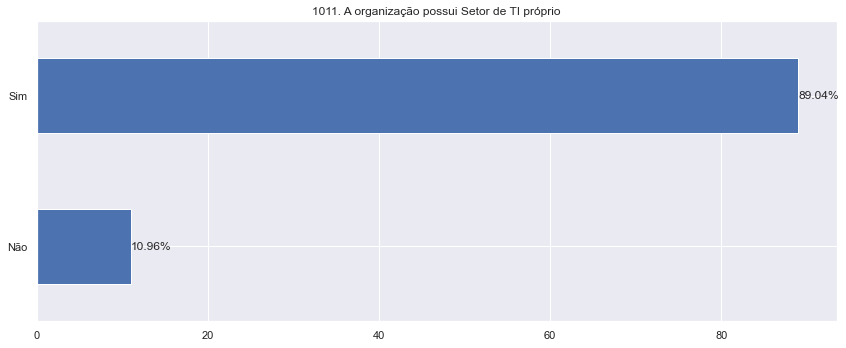

In [5]:
#1011. A organização possui Setor de TI próprio
ax = (100*df_secao_setic['q1011'].value_counts()/df_secao_setic['q1011'].count())[['Não', 'Sim']] \
    .plot.barh(title='1011. A organização possui Setor de TI próprio', figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
plt.tight_layout()

#### Organizações sem Setor de TI próprio

In [26]:
sorted(df_secao_setic[df_secao_setic['q1011'] == 'Não'].index)

['CASERJ', 'FIPERJ', 'FTMRJ', 'GVG', 'IASERJ', 'SEAS', 'SEGOV', 'TURISRIO']

#### Razões pela não existência de Setor de TI próprio

In [13]:
df_secao_setic[df_secao_setic['q1011'] == 'Não'].filter(regex='^q1011nao').sort_values(by='attribute_1')

,q1011nao
attribute_1,
CASERJ,"DIRADM – Diretoria de Administração, a partir de então denominada simplesmente como DIRADM, Órgão que também participa da composição da empresa pública CA-SERJ – Companhia de Armazéns e Silos do Estado do Rio de Janeiro, inscrita no C.N.P.J. sob o nº 33.135.641/0001-02, com sede na Avenida Brasil nº 19.001, 3º andar, Irajá, Rio de Janeiro, RJ, CEP 21530-000, também, a partir de então denominada apenas como CASERJ ou COMPANHIA, então vinculada à SEAPPA – Secretaria de Estado de Agricultura, Pecuária, Pesca e Abastecimento, facilitando-se pela simples referência de denominação SEAPPA, que outrora figurou sob a antiga denominação SEDRAP – Secretaria de Estado de Desenvolvimento Regional, Abastecimento e Pesca, DIRADM esta que aqui comparece para apresentar o seu Relatório de Atividades, em razão das considerações abaixo pormenorizadas.\n\tPreliminarmente, é de se ter em importante consideração que a atual Diretoria Executiva da CASERJ assumiu a gestão da COMPANHIA, pela primeira vez, somente em dez de abril de 2019, tendo sido complementada a composição atual, pelo titular da Diretoria de Administração, apenas no ano de 2021.\n\tÉ de se destacar igualmente que apesar das intempéries que identificamos mesmo antes de aceitarmos o desafio que nos foi apresentado, jamais foram estes capazes de interromper as atividades desenvolvidas pela empresa com quem foi celebrado o Termo de Cooperação Técnica nº 001/2011 (15285824 e 17307224), a CEASA-RJ – Centrais de Abastecimento do Estado do Rio de Janeiro S/A, que em seguida será referenciada somente por CEASA.\n\tCitamos CEASA no contexto deste relatório, pois todos os empregados desta COMPANHIA foram cedidos à primeira, conforme tema retratado em sede dos processos administrativos autuados como E-06/000.026/2011, E-06/20.903/2012, E-06/21590/2012 e SEI-020005/000038/2021, que culminaram no Termo de Cooperação Técnica nº 001, de 1º de março de 2011 (documento SEI nº 17307224).\n\tPor decorrência deste, CEASA arca com Recursos próprios e oriundos da Fonte 230, para a satisfação dos custos dos benefícios trabalhistas acessórios à remuneração salarial, esta última, então suportada pelo próprio Estado do Rio de Janeiro, por movimentações financeiras / contábeis, assim, compromissos satisfeitos com Recursos da Fonte 100 (segundo o Classificador de Planejamento e Orçamento elaborado pela SE-FAZ-RJ).\n\tTudo isto se traz à colação, porque, como se observa do bojo do eletrônico E-06/20208/2011, por meio do Ofício PRESI CEASA N. 179, de 28 de abril de 2011 (7633477, folhas 02/03) e posterior manifestação PRESI desta COMPANHIA (7633477, folha 04), foram iniciados os trabalhos de possível transformação desta – naquela ocasião – cogitando-se pela possibilidade de incorporação ou fusão, pela CEASA.\n \tConforme regras estatuídas nos artigos 219, 220, 221, 222, 223 e seguintes Lei nº 6.404, de 15 de dezembro de 1976, dependem do animus dos acionistas – até unânime em certas condições – que se possa dar início ou continu..."
FIPERJ,"DE ACORDO COM O DECRETO ORGANIZACIONAL, N° 16.444 DE 1991, NECESSIDADE E PLANEJAMENTO DE MUDANÇA."
FTMRJ,"Sim, necessita. Ocorre que o Setor de TI não existe no regimento interno do òrgão. Todo o trabalho que envolve tecnologia da informação é efetuado por dois funcionário qualificados e com formação na área."
GVG,"Todo suporte de TI para a Vice-Governadoria é fornecido pela Secretaria de Estado da Casa Civil, com base no Decreto Estadual nº 45.113/2015."
IASERJ,A SECRETARIA ESTADUAL DE SAÚDE É A RESPONSÁVEL PELA ADMINISTRAÇÃO DOS RECURSOS QUE ENVOLVEM O IASERJ.
SEAS,"- A TI da Secretaria é atendida pelo Instituto Estadual do Ambiente - INEA, através de sua Gerência de Tecnologia (GERTEC);\n"
SEGOV,"Resolução Conjunta SECC/SEGOV N° 17 de 09 de março de 2021, estabelece normas de cooperação técnica entre a Secretaria de Estado da Casa Civil e a Secretaria de Estado de Governo no âmbito de suas atividades."
TURISRIO,"Pelo fato da TurisRio ser vincu

#### Pós análise das razões, organizações sem Setor de TI próprio

Desconsiderou-se a resposta da Fundação Theatro Municipal - FTMRJ, uma vez que essa afirma que possui uma estrutura de TI e que apenas não está normatizada.

### 1021. A organização tem conhecimento dos normativos expedidos pelo Diretor Geral do SETIC (PRODERJ)

In [38]:
df_secao_setic['q1021'].value_counts()

Sim    64
Não     1
Name: q1021, dtype: int64

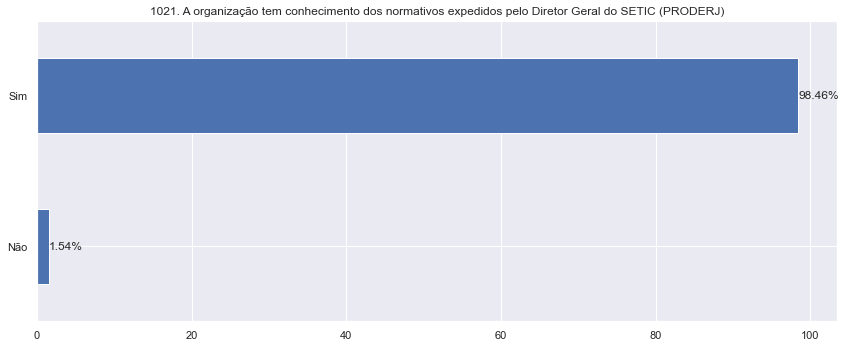

In [7]:
#1021. A organização tem conhecimento dos normativos expedidos pelo Diretor Geral do SETIC (PRODERJ)

ax = (100*df_secao_setic['q1021'].value_counts()/df_secao_setic['q1021'].count())[['Não', 'Sim']] \
    .plot.barh(title='1021. A organização tem conhecimento dos normativos expedidos pelo Diretor Geral do SETIC (PRODERJ)', figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()

#### Normativos mais conhecidos

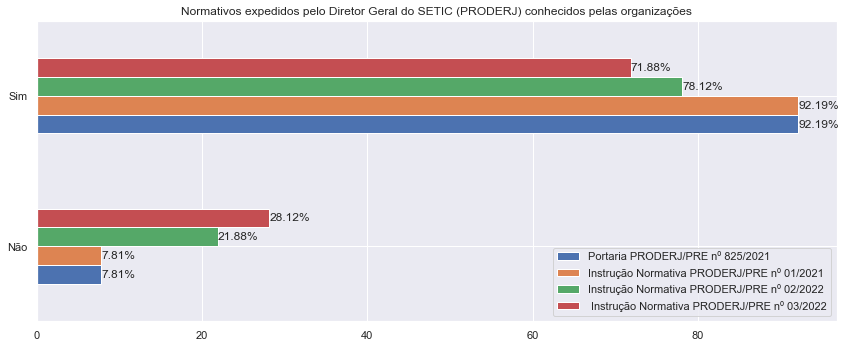

In [30]:
ax = (100*df_secao_setic.filter(regex='^q1021ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1021ext').count()) \
    .reindex(index = ['Não','Sim']) \
    .plot.barh(title='Normativos expedidos pelo Diretor Geral do SETIC (PRODERJ) conhecidos pelas organizações', figsize=(12, 5))

ax.legend(['Portaria PRODERJ/PRE nº 825/2021', 'Instrução Normativa PRODERJ/PRE nº 01/2021', 'Instrução Normativa PRODERJ/PRE nº 02/2022', ' Instrução Normativa PRODERJ/PRE nº 03/2022']);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Justificativas pelo não conhecimento

In [39]:
df_secao_setic[df_secao_setic['q1021']== 'Não'].filter(regex='^q1021')

,q1021,q1021ext[A],q1021ext[B],q1021ext[C],q1021ext[D],q1021raznao
attribute_1,,,,,,
FIA/RJ,Não,NaN,NaN,NaN,NaN,A Gestão de TI atual é nova e não teve nenhum acesso a esta documentação.


### 1022. A organização atende a Portaria PRODERJ/PRE nº 825/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).


In [13]:
df_secao_setic['q1022'].value_counts()

Adota em maior parte ou totalmente.                   25
Adota em menor parte.                                 15
Há decisão formal ou plano aprovado para adotá-lo.     9
Adota parcialmente.                                    9
Não adota.                                             5
Não se aplica.                                         2
Name: q1022, dtype: int64

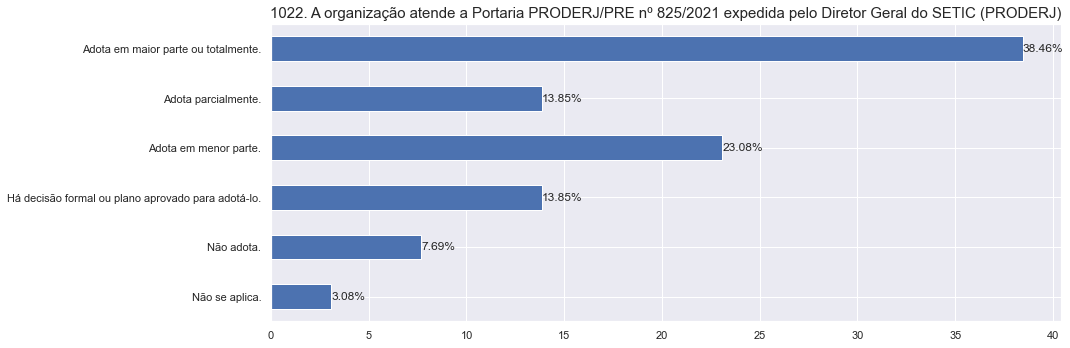

In [8]:
#1022. A organização atende a Portaria PRODERJ/PRE nº 825/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).

ax = ((100*df_secao_setic['q1022'].value_counts()/df_secao_setic['q1022'].count())[
    ['Não se aplica.', 'Não adota.', 'Há decisão formal ou plano aprovado para adotá-lo.',
    'Adota em menor parte.', 'Adota parcialmente.', 'Adota em maior parte ou totalmente.']
]) \
    .plot.barh(figsize=(15, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
ax.set_title('1022. A organização atende a Portaria PRODERJ/PRE nº 825/2021 expedida pelo Diretor Geral do SETIC (PRODERJ)', fontsize=15)

plt.tight_layout()

#### Práticas mais adotadas


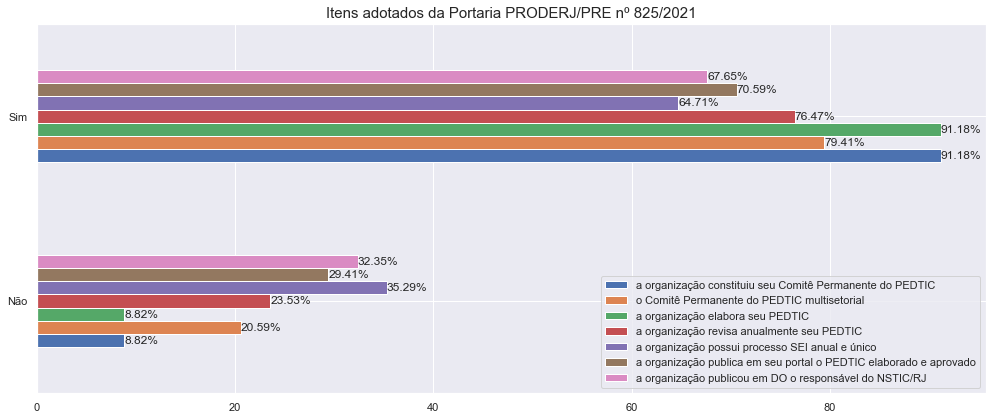

In [9]:
#Praticas mais adotadas

ax = (100*df_secao_setic.filter(regex='^q1022ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1022ext').count()) \
    .reindex(index = ['Não','Sim']) \
    .plot.barh(figsize=(14, 6))

ax.legend([
    'a organização constituiu seu Comitê Permanente do PEDTIC', 
    'o Comitê Permanente do PEDTIC multisetorial', 
    'a organização elabora seu PEDTIC', 
    'a organização revisa anualmente seu PEDTIC',
    'a organização possui processo SEI anual e único',
    'a organização publica em seu portal o PEDTIC elaborado e aprovado',
    'a organização publicou em DO o responsável do NSTIC/RJ',
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

ax.set_title('Itens adotados da Portaria PRODERJ/PRE nº 825/2021', fontsize=15)
plt.tight_layout()

#### Motivos da não aplicabilidade

In [54]:
#Motivos da não aplicabilidade
df_secao_setic[df_secao_setic['q1022'] == 'Não se aplica.'].filter(regex='^q1022').filter(regex='nsa|lei|est|raz')

,q1022nsa,q1022lei,q1022est,q1022raz
attribute_1,,,,
AGERIO,Não se aplica por outras razões.,NaN,NaN,"A instituição da AgeRio foi autorizada pela Lei Estadual nº 3.517, de 27 de dezembro de 2000, e concretizada através do Decreto Estadual nº 32.376, de 12 de dezembro de 2002. O Art. 1º do Decreto estabeleceu a criação da AgeRio sob a forma de sociedade anônima de economia mista, de capital fechado, autorizado, com personalidade jurídica de direito privado, autonomia administrativa e financeira. Além disso, dada a natureza não dependente da instituição, nos termos do art. 2º da Lei de Responsabilidade Fiscal (LC 101/2000), os dispostos pelos Art. 89 e Art. 90 da Lei nº 13.303, de 30 de junho de 2016 reforçam o princípio da autonomia administrativa e financeira da AgeRio. Nesse contexto, a AgeRio segue disposições próprias acerca da governança de tecnologia, sendo o Comitê de TI da instituição o órgão responsável pela discussão e opinamento sobre questões táticas e estratégicas de TI, inclusive sobre o Plano Estratégico e Diretor de TI."
PGE,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A Constituição do ERJ, em seu Paragrafo 5 do artigo 176, na forma regulamentada pela Lei Complementar Estadual 15 de 1980, especialmente no Artigo 2, garante a autonomia administrativa e financeira da Procuradoria Geral do Estado do Rio de Janeiro. Em razão da autonomia deste Órgão, quase todos os itens da Portaria PRODERJ/PRE nº 825/2021 acabam sendo observados por serem considerados boas práticas de governança de TI. Assim, adotando a metodologia prevista para o caso de marcação do item “adota na maior parte”, este Órgão pode informar que elabora seu PEDTIC (c), revisa anualmente seu PEDTIC (d), possui processo SEI anual e único para registrar a elaboração e revisão de seu PEDTIC, assim como registrar as atas das reuniões do Comitê (e), publica em seu próprio portal o PEDTIC elaborado e aprovado (f) e publicou em Diário Oficial a indicação do principal responsável do NSTIC/RJ (g).",NaN,NaN


### 1023. A organização atende a Instrução Normativa PRODERJ/PRE nº 01/2021 expedida pelo Diretor Geral do SETIC (PRODERJ).

In [12]:
df_secao_setic['q1023'].value_counts()

Adota em maior parte ou totalmente.                   29
Adota em menor parte.                                 21
Há decisão formal ou plano aprovado para adotá-lo.     6
Adota parcialmente.                                    4
Não se aplica.                                         3
Não adota.                                             2
Name: q1023, dtype: int64

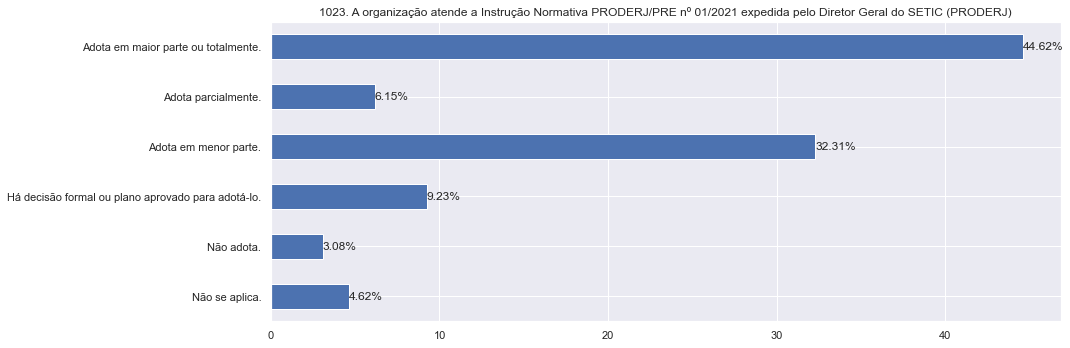

In [10]:
ax = ((100*df_secao_setic['q1023'].value_counts()/df_secao_setic['q1023'].count())[
    ['Não se aplica.', 'Não adota.', 'Há decisão formal ou plano aprovado para adotá-lo.',
    'Adota em menor parte.', 'Adota parcialmente.', 'Adota em maior parte ou totalmente.']
]) \
    .plot.barh(title='1023. A organização atende a Instrução Normativa PRODERJ/PRE nº 01/2021 expedida pelo Diretor Geral do SETIC (PRODERJ)', figsize=(15, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Práticas mais adotadas

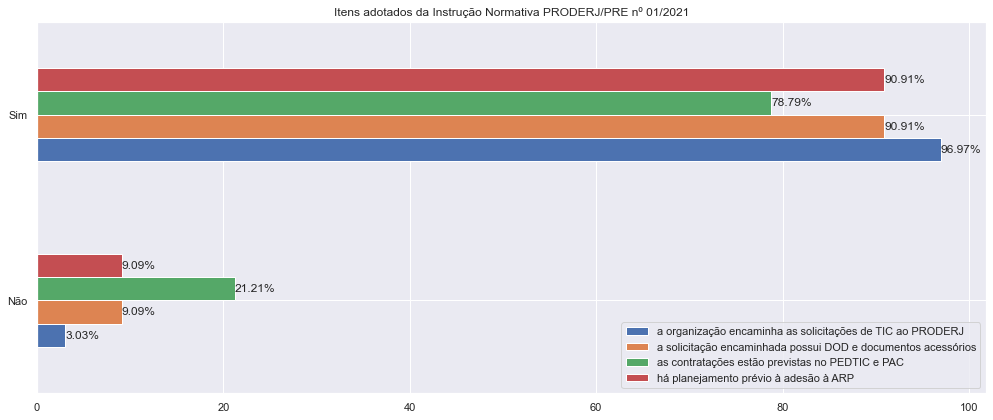

In [58]:
#Praticas mais adotadas
df_secao_setic.filter(regex='^q1023ext').apply(pd.value_counts)

ax = (100*df_secao_setic.filter(regex='^q1023ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1023ext').count()) \
    .reindex(index = ['Não','Sim']) \
    .plot.barh(title='Itens adotados da Instrução Normativa PRODERJ/PRE nº 01/2021', figsize=(14, 6))

ax.legend([
    'a organização encaminha as solicitações de TIC ao PRODERJ', 
    'a solicitação encaminhada possui DOD e documentos acessórios', 
    'as contratações estão previstas no PEDTIC e PAC', 
    'há planejamento prévio à adesão à ARP'    
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Motivos da não aplicabilidade


In [56]:
df_secao_setic[df_secao_setic['q1023'] == 'Não se aplica.'].filter(regex='^q1023').filter(regex='nsa|lei|est|raz')

,q1023nsa,q1023lei,q1023est,q1023raz
attribute_1,,,,
AGERIO,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A instituição da AgeRio foi autorizada pela Lei Estadual nº 3.517, de 27 de dezembro de 2000, e concretizada através do Decreto Estadual nº 32.376, de 12 de dezembro de 2002. O Art. 1º do Decreto estabeleceu a criação da Agência sob a forma de sociedade anônima de economia mista, de capital fechado, autorizado, com personalidade jurídica de direito privado, autonomia administrativa e financeira. Além disso, dada a natureza não dependente da instituição, nos termos do art. 2º da Lei de Responsabilidade Fiscal (LC 101/2000), os dispostos pelos Art. 89 e Art. 90 da Lei nº 13.303, de 30 de junho de 2016 reforçam o princípio da autonomia administrativa e financeira da Agência. Nesse contexto, a AgeRio segue disposições próprias acerca da governança de tecnologia, sendo o Comitê de TI da instituição o órgão responsável pela discussão e opinamento sobre questões táticas e estratégicas de TI, inclusive sobre o Plano Estratégico e Diretor de TI.",NaN,NaN
PGE,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A Constituição do ERJ, em seu Paragrafo 5 do artigo 176, na forma regulamentada pela Lei Complementar Estadual 15 de 1980, especialmente no Artigo 2, garante a autonomia administrativa e financeira da Procuradoria Geral do Estado do Rio de Janeiro.",NaN,NaN
FLXIII,Não se aplica por outras razões.,NaN,NaN,Não possui


### 1024. A organização atende a Instrução Normativa PRODERJ/PRE nº 02/2022 expedida pelo Diretor Geral do SETIC (PRODERJ).

In [17]:
df_secao_setic['q1024'].value_counts()

Adota em menor parte.                                 25
Há decisão formal ou plano aprovado para adotá-lo.    12
Não adota.                                            11
Adota em maior parte ou totalmente.                   10
Adota parcialmente.                                    4
Não se aplica.                                         3
Name: q1024, dtype: int64

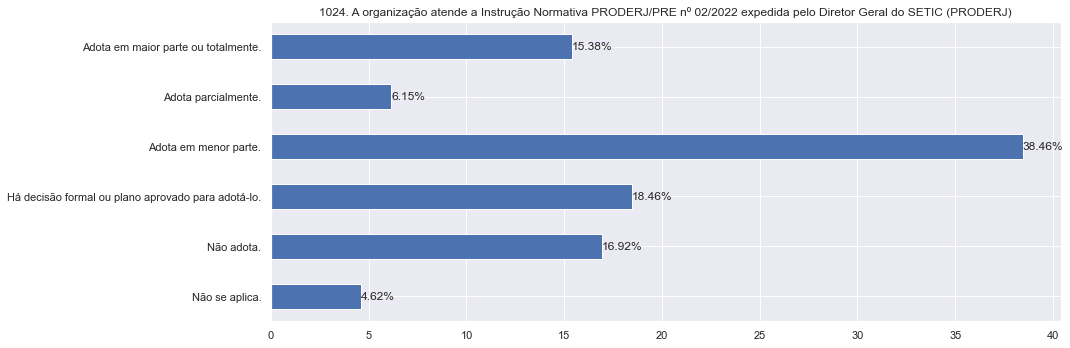

In [59]:
ax = ((100*df_secao_setic['q1024'].value_counts()/df_secao_setic['q1024'].count())[
    ['Não se aplica.', 'Não adota.', 'Há decisão formal ou plano aprovado para adotá-lo.',
    'Adota em menor parte.', 'Adota parcialmente.', 'Adota em maior parte ou totalmente.']
]) \
    .plot.barh(title='1024. A organização atende a Instrução Normativa PRODERJ/PRE nº 02/2022 expedida pelo Diretor Geral do SETIC (PRODERJ)', figsize=(15, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Práticas mais adotadas


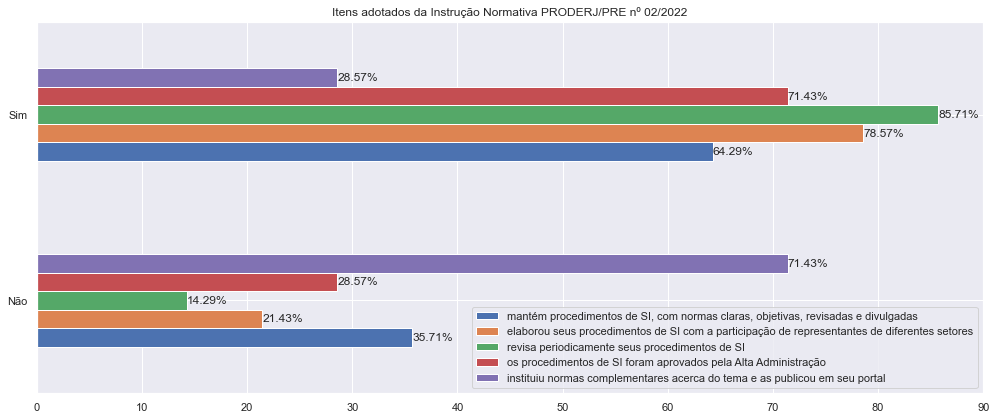

In [60]:
ax = (100*df_secao_setic.filter(regex='^q1024ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1024ext').count()) \
    .plot.barh(title='Itens adotados da Instrução Normativa PRODERJ/PRE nº 02/2022', figsize=(14, 6))

ax.legend([
    'mantém procedimentos de SI, com normas claras, objetivas, revisadas e divulgadas', 
    'elaborou seus procedimentos de SI com a participação de representantes de diferentes setores', 
    'revisa periodicamente seus procedimentos de SI', 
    'os procedimentos de SI foram aprovados pela Alta Administração',
    'instituiu normas complementares acerca do tema e as publicou em seu portal'
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Motivos da não aplicabilidade


In [59]:
df_secao_setic[df_secao_setic['q1024'] == 'Não se aplica.'].filter(regex='^q1024').filter(regex='nsa|lei|est|raz')

,q1024nsa,q1024lei,q1024est,q1024raz
attribute_1,,,,
SETD,Não se aplica por outras razões.,NaN,NaN,"A Secretaria de Estado de Transformação Digital (SETD) foi criada por meio do Decreto Estadual nº 48.151, de 08 de julho de 2022, e foi estruturada pelo Decreto Estadual nº 48.378, de 01 de março de 2023. A partir disso, iniciaram-se as operações com as competências definidas, a estrutura organizada e com recursos necessários. A SETD, por estar utilizando o mesmo ambiente e infraestrutura do PRODERJ, emprega todos os instrumentos de segurança da informação e procedimentos operacionais já disponibilizados pela instituição. Mesmo assim, existe orientação para a devida adoção de procedimentos quanto às questões de segurança da informação por parte da Secretaria, logo após as aprovações do PEI e do PEDTIC."
PGE,"Não se aplica porque há lei e/ou norma, externa à organização, que impede a implementação desta prática.","A Constituição do ERJ, em seu Paragrafo 5 do artigo 176, na forma regulamentada pela Lei Complementar Estadual 15 de 1980, especialmente no Artigo 2, garante a autonomia administrativa e financeira da Procuradoria Geral do Estado do Rio de Janeiro. Em razão da autonomia deste Órgão, parte dos itens da Instrução Normativa PRODERJ/PRE nº 02/2021 são adotados por serem considerados boas práticas de segurança da informação. Assim, adotando a metodologia prevista para o caso de marcação do item “adota na maior parte”, este Órgão pode informar que revisa periodicamente seus procedimentos de segurança da informação (c) e que os procedimentos de segurança da informação foram aprovados pela Alta Administração deste Órgão (d).",NaN,NaN
FLXIII,Não se aplica por outras razões.,NaN,NaN,Não possui


### 1025. A organização desenvolve, sustenta e/ou hospeda seu site ou portal nos ambientes do PRODERJ.


In [20]:
df_secao_setic['q1025'].value_counts()

Sim    46
Não    19
Name: q1025, dtype: int64

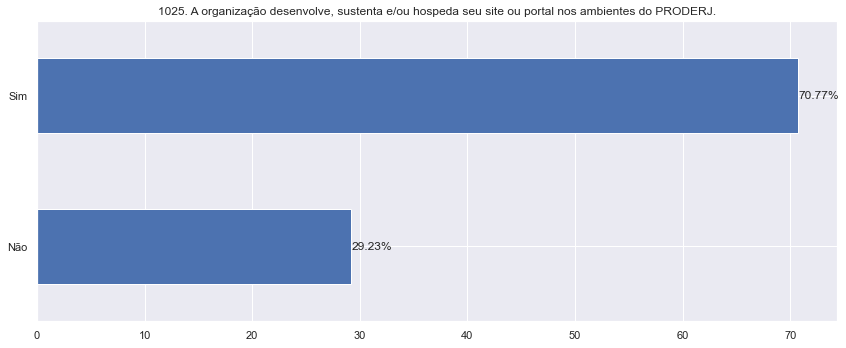

In [61]:
ax = ((100*df_secao_setic['q1025'].value_counts()/df_secao_setic['q1025'].count())[['Não', 'Sim']]) \
    .plot.barh(title='1025. A organização desenvolve, sustenta e/ou hospeda seu site ou portal nos ambientes do PRODERJ.', figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Modelos de adoção

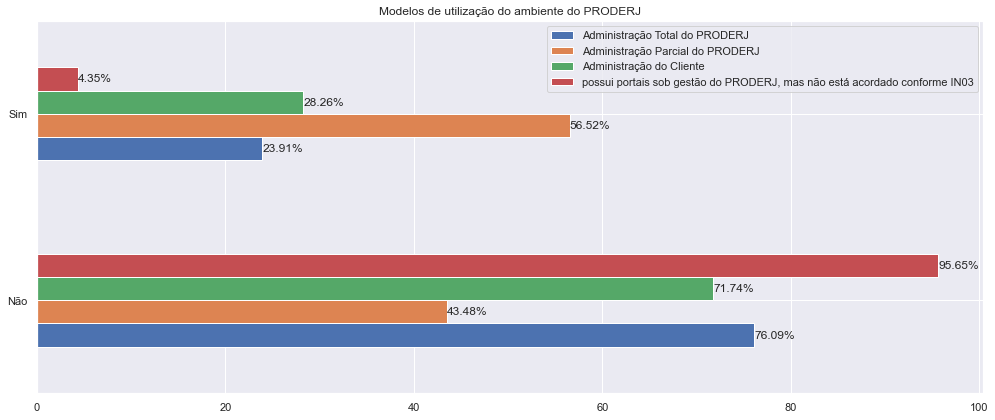

In [62]:
ax = (100*df_secao_setic.filter(regex='^q1025ext').apply(pd.value_counts) / df_secao_setic.filter(regex='^q1025ext').count()) \
    .plot.barh(title='Modelos de utilização do ambiente do PRODERJ', figsize=(14, 6))

ax.legend([
    'Administração Total do PRODERJ', 
    'Administração Parcial do PRODERJ', 
    'Administração do Cliente', 
    'possui portais sob gestão do PRODERJ, mas não está acordado conforme IN03'
]);

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Motivos da não utilização


In [44]:
df_secao_setic[df_secao_setic['q1025'] == 'Não'].filter(regex='^q1025raz').sort_values(by='attribute_1')

,q1025raznao
attribute_1,
AGERIO,"Por conta da autonomia administrativa da agência conforme detalhado nas respostas anteriores, a saber: A instituição da AgeRio foi autorizada pela Lei Estadual nº 3.517, de 27 de dezembro de 2000, e concretizada através do Decreto Estadual nº 32.376, de 12 de dezembro de 2002. O Art. 1º do Decreto estabeleceu a criação da Agência sob a forma de sociedade anônima de economia mista, de capital fechado, autorizado, com personalidade jurídica de direito privado, autonomia administrativa e financeira. Além disso, dada a natureza não dependente da instituição, nos termos do art. 2º da Lei de Responsabilidade Fiscal (LC 101/2000), os dispostos pelos Art. 89 e Art. 90 da Lei nº 13.303, de 30 de junho de 2016 reforçam o princípio da autonomia administrativa e financeira da Agência. Nesse contexto, a AgeRio segue disposições próprias acerca da governança de tecnologia, sendo o Comitê de TI da instituição o órgão responsável pela discussão e opinamento sobre questões táticas e estratégicas de TI, inclusive sobre o Plano Estratégico e Diretor de TI."
AGETRANSP,"Houve dificuldades na manutenção e suporte quando hospedados o site da Agência no PRODERJ, assim a gestão do órgão à época decidiu realizar a hospedagem localmente na sede própria."
CECIERJ,"A fundação, por ser uma instituição que possui em suas atividades finalísticas a pesquisa e extensão, conta em seus quadros com uma equipe de servidores estáveis, incluindo profissionais da área de TIC (analistas de sistemas, redes e suporte, além de programadores e webdesingers) conforme DECRETO N° 42.765 DE 22 DE DEZEMBRO DE 2010. A fundação CECIERJ possui um acordo, sem custo, de hospedagem de equipamentos com a RedeRio/FAPERJ, que disponibiliza um espaço com conectividade e infraestrutura elétrica e de refrigeração para os servidores responsáveis por prover acesso público aos diversos serviços digitais oferecidos pela fundação. Além disso, já foi iniciado o processo de migração destes equipamentos para o Rio Science Datacenter (RSDC), um ambiente de alta disponibilidade que continuará permitindo a hospedagem dos nossos equipamentos sem custo."
CODIN,"A CODIN mantém site externo em provedor particular, com informações necessárias às atividades da empresa e mantém site interno (Intranet) para os serviços previstos para os colaboradores."
DETRAN,O DETRAN sempre possuiu infraestrutura própria apartada do PRODERJ.
DETRO,"Devido a troca de gestão, eu, na qualidade de Coordenadora desta COOTI, cumpro mencionar que assumi a T.I desta autarquia em 17 de Janeiro de 2023, todavia estamos adotando medidas cabíveis para melhor atender o orgão."
FAETEC,"EXISTE EM SERVIDOR LOCAL, MAS MINHA NOVA GESTÃO JA INICIOU O PROCESSO PARA NOVO PORTAL, QUE ESTAVA PARALISADO PELA ANTIGA GESTÃO, E AUTENTICAÇÃO AD JUNTO AO PRODERJ. ATUALMENTE nosso site NÃO ESTÁ ATUALIZADO e COM TODAS AS CERTIFICAÇÕES DE SEGURANÇA, \nMAS ATUALMENTE NAO TEM O PADRÃO HTTPS, JA FOI DETERMINADO QUE SEJA IMPLEMENTADO."
FAPERJ,No momento existe um estudo para migrar alguns serviços para o PRODERJ.
FMIS,"O site institucional do MIS foi desenvolvido e é administrado pela SECEC. O mesmo está hospedado no PRODERJ, também pela SECEC. O site da Web Rádio MIS RJ é desenvolvido e hospedado por empresa terceirizada. O Site do banco de dados é desenvolvido e administrado pelo responsável do Banco de Dados e é hospedado em empresa terceirizada."


### Quadro geral de cumprimento à Portaria 825, IN01 e IN02

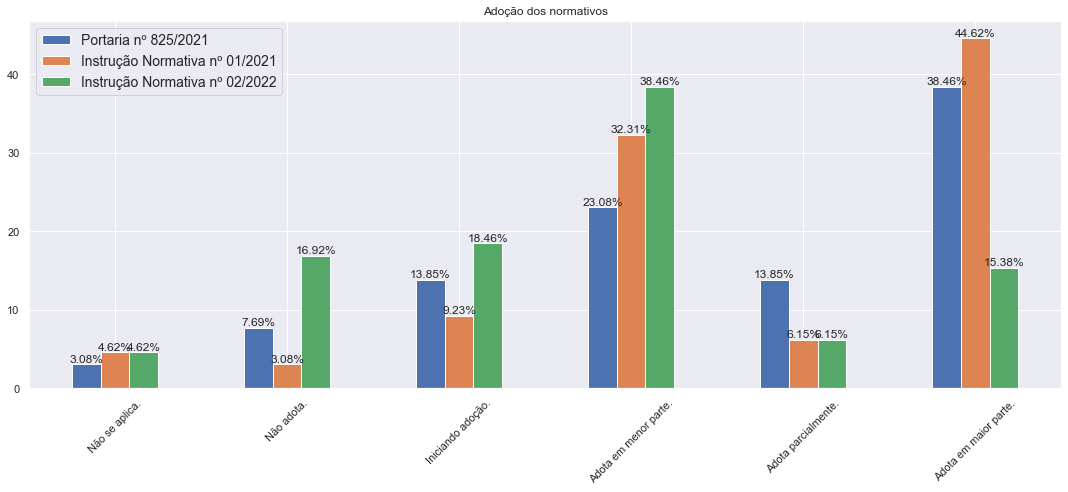

In [56]:
ax = (100*df_secao_setic[['q1022', 'q1023', 'q1024']].apply(pd.value_counts)/65) \
    .reindex([ 
        'Não se aplica.', 'Não adota.', 'Há decisão formal ou plano aprovado para adotá-lo.',
        'Adota em menor parte.', 'Adota parcialmente.', 'Adota em maior parte ou totalmente.'
    ]) \
    .rename(index={
        'Há decisão formal ou plano aprovado para adotá-lo.': 'Iniciando adoção.',
        'Adota em maior parte ou totalmente.': 'Adota em maior parte.'
    })\
    .plot.bar(title='Adoção dos normativos', figsize=(15, 7), rot=45)

ax.legend([
    'Portaria nº 825/2021', 
    'Instrução Normativa nº 01/2021', 
    'Instrução Normativa nº 02/2022',
], fontsize=14)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

# Avaliação de satisfação das organizações quanto ao SETIC

### 1031. Nos últimos doze meses, o Gestor de TI recebeu comunicações do Diretor Geral do SETIC (PRODERJ)?

In [45]:
df_secao_setic['q1031'].value_counts()

Sim    59
Não     6
Name: q1031, dtype: int64

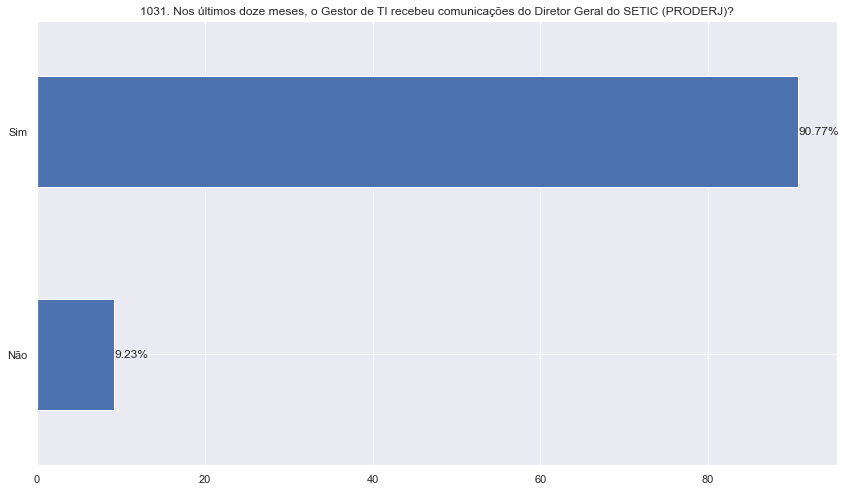

In [63]:
#1031. Nos últimos doze meses, o Gestor de TI recebeu comunicações do Diretor Geral do SETIC (PRODERJ)?

ax = ((100*df_secao_setic['q1031'].value_counts()/df_secao_setic['q1031'].count())[['Não', 'Sim']]) \
    .plot.barh(title='1031. Nos últimos doze meses, o Gestor de TI recebeu comunicações do Diretor Geral do SETIC (PRODERJ)?', figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Não recepção de comunicação

In [126]:
df_secao_setic[df_secao_setic['q1031'] == 'Não'].filter(regex='^q1031')

,q1031
attribute_1,
FSC,Não
CODIN,Não
CEASA,Não
JUCERJA,Não
AGETRANSP,Não
EMATER,Não


### 1032. Considerando os meios de comunicação disponibilizadas pelo Diretor Geral (PRODERJ), qual a satisfação do Gestor de TI em relação à relevância da comunicação do Diretor Geral com os órgãos setoriais no SETIC?


In [46]:
df_secao_setic['q1032'].value_counts()

Satisfeito          41
Muito Satisfeito    17
Insatisfeito         1
Name: q1032, dtype: int64

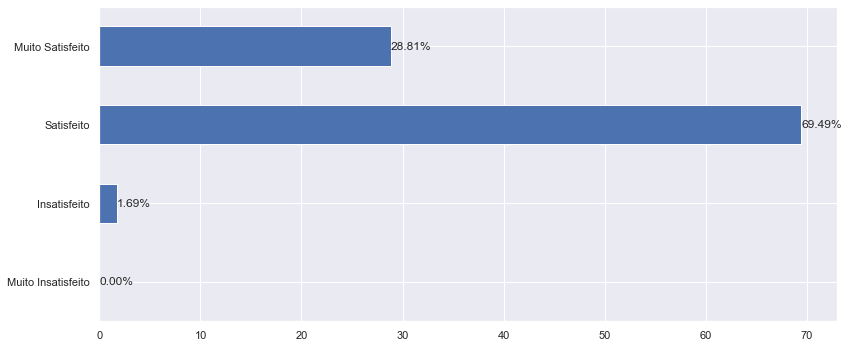

In [64]:
#1032. Considerando os meios de comunicação disponibilizadas pelo Diretor Geral (PRODERJ), qual a satisfação
#do Gestor de TI em relação à relevância da comunicação do Diretor Geral com os órgãos setoriais no SETIC?

dictionary = {'Muito Satisfeito': 0, 'Satisfeito': 0, 'Insatisfeito': 0, 'Muito Insatisfeito': 0}
dados = pd.DataFrame.from_dict({**dictionary, **df_secao_setic['q1032'].value_counts().to_dict()}, orient='index')

ax = ((100*dados/df_secao_setic['q1032'].count())) \
    .reindex(index=['Muito Insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito Satisfeito']) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

ax.get_legend().set_visible(False)

plt.tight_layout()

#### Opiniões positivas acerca da relevância da comunicação do Diretor Geral

In [68]:
df_secao_setic[
    (df_secao_setic['q1032'] == 'Satisfeito') | 
    (df_secao_setic['q1032'] == 'Muito Satisfeito')
].filter(regex='^q1032').sort_values(by='attribute_1')

,q1032,q1032raz
attribute_1,,
AGENERSA,Satisfeito,"Melhorar a comunicação dos objetos das ARP e o planejamento dessas Atas, informando aos órgãos a priorização destas atas e as datas estimadas para o PLS e para a disponibilização da mesma. Isso facilitaria o planejamento dos órgãos."
AGERIO,Muito Satisfeito,O PRODERJ é muito ativo em buscar manter a comunicação ativa e eficaz com os órgãos. Faço parte do grupo de WhatsApp e sempre recebo os ofícios pelo sei ou por email .
CECIERJ,Satisfeito,As comunicações realizadas colaboram e fortalecem nossas preocupações na formulação de conformidades.
CEHAB,Satisfeito,"As nossas maquinas servidoras estão hospedadas no DATACENTER do PRODERJ, temos um contrato inclusive com suporte técnico, as nossas contratações de TIs,\nsão através de ATA de Registro de Preços/PRODERJ ou anuência do respectivo órgão."
CENTRAL,Muito Satisfeito,"Recebemos suporte via todos os meios digitais, inclusive telefônico."
CEPERJ,Satisfeito,O PRODERJ geralmente expede circulares informando sobre eventos e ATAS de Registro de Preço.
CGE,Satisfeito,Falta de divulgação dos planos de suprimento elaborados
CODERTE,Satisfeito,"A plataforma Whatsapp, lista de e-mails, comunicação institucional por ofícios e a Plataforma do AtendeRJ (Central de Atendimento) tem contribuído muito na melhoria da comunicação."
DEGASE,Satisfeito,Todas as demandas apresentadas diretamente ao PRODERJ tiveram feedback em tempo hábil e satisfatório.


#### Opiniões negativas acerca da relevância da comunicação do Diretor Geral

In [48]:
df_secao_setic[
    (df_secao_setic['q1032'] == 'Insatisfeito') | 
    (df_secao_setic['q1032'] == 'Muito Insatisfeito')
].filter(regex='^q1032')

,q1032,q1032raz
attribute_1,,
SEEDUC,Insatisfeito,"Embora os meios de comunicação sejam diversificados, alguns processos relevantes não perpassam aos veículos habituais e oficiais de comunicação com as áreas técnicas das SEEDUC-RJ, em que demandas formais, muitas das vezes são abordadas no grupo de 'WhatsApp'. A título de exemplo, citam-se os planos de suprimentos, que deveriam ser tratados por intermédio dos canais de compras públicas RJ e/ou pela interface do SIGA ou Rede Logística com envio de mensagem quando da criação de novos PLS. Em que pese os mecanismos de desburocratização, de fato, algumas oportunidades são perdidas por essa questão."


#### Estatísticas

In [51]:
aux = df_secao_setic['q1032']
aux = aux.replace({'Muito Satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito Insatisfeito': 1})
aux.describe()

count    59.000000
mean      3.271186
std       0.485319
min       2.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       4.000000
Name: q1032, dtype: float64

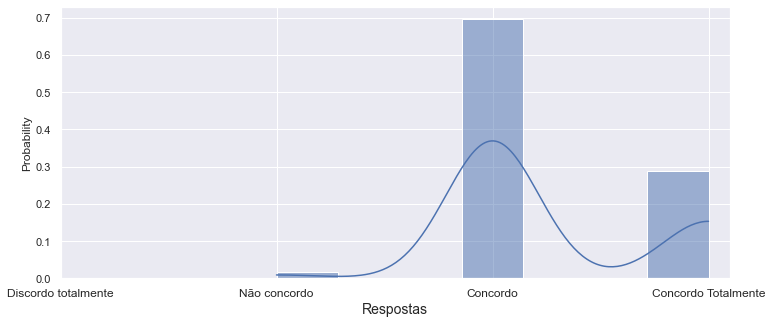

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
#sns.boxplot(x=aux, fill=False, showmeans=True,   ax=ax)
#sns.displot(x=aux, fill=False, ax=ax)
sns.histplot(x=aux, ax=ax, stat='probability', kde=True)

plt.xlabel("Respostas", size=14)
ax.set_xticks(ticks=[1,2,3,4], labels=['Discordo totalmente', 'Não concordo', 'Concordo', 'Concordo Totalmente'], size=12)

### 1033. Nos últimos doze meses, o Gestor de TI recebeu auxílio e/ou orientação do Diretor Geral do SETIC (PRODERJ)?

In [69]:
df_secao_setic['q1033'].value_counts()

Sim    54
Não    11
Name: q1033, dtype: int64

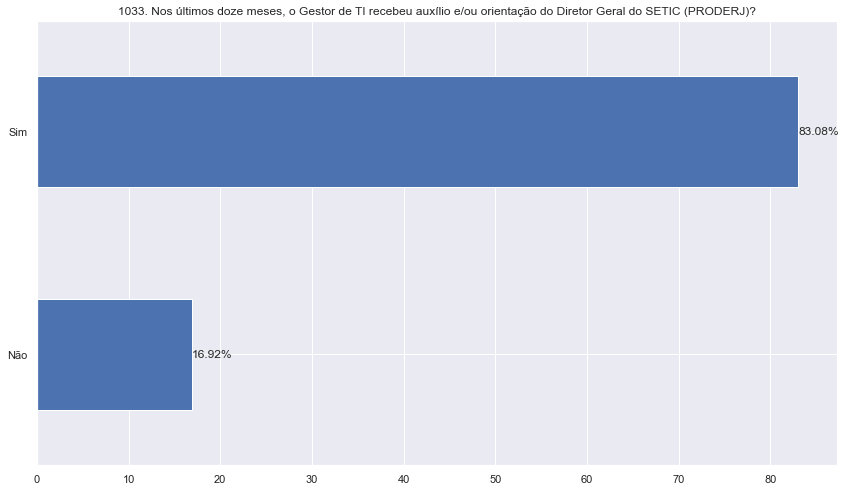

In [65]:
#1033. Nos últimos doze meses, o Gestor de TI recebeu auxílio e/ou orientação do Diretor Geral do SETIC (PRODERJ)?

ax = ((100*df_secao_setic['q1033'].value_counts()/df_secao_setic['q1033'].count())[['Não', 'Sim']]) \
    .plot.barh(title='1033. Nos últimos doze meses, o Gestor de TI recebeu auxílio e/ou orientação do Diretor Geral do SETIC (PRODERJ)?', figsize=(12, 7))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')
    
plt.tight_layout()

#### Não recepção de comunicação

In [71]:
df_secao_setic[df_secao_setic['q1033'] == 'Não'].filter(regex='^q1033')

,q1033
attribute_1,
FSC,Não
CODIN,Não
SECTI,Não
CEASA,Não
RJPREV,Não
AGETRANSP,Não
SEEDUC,Não
IVB,Não
SEPM,Não


### 1034. Qual a satisfação do Gestor de TI em relação ao auxílio e orientação prestados pelo Diretor Geral (PRODERJ) aos órgãos setoriais do SETIC?

In [105]:
df_secao_setic['q1034'].value_counts()

Satisfeito            32
Muito satisfeito      13
Muito insatisfeito     6
Insatisfeito           3
Name: q1034, dtype: int64

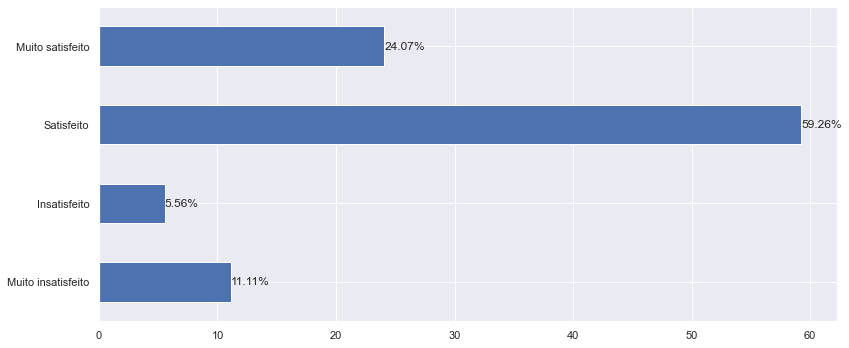

In [66]:
#1034. Qual a satisfação do Gestor de TI em relação ao auxílio e orientação prestados pelo Diretor Geral (PRODERJ)
#aos órgãos setoriais do SETIC?

dictionary = {'Muito satisfeito': 0, 'Satisfeito': 0, 'Insatisfeito': 0, 'Muito insatisfeito': 0}
dados = pd.DataFrame.from_dict({**dictionary, **df_secao_setic['q1034'].value_counts().to_dict()}, orient='index')

ax = ((100*dados/df_secao_setic['q1034'].count())) \
    .reindex(index=['Muito insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito satisfeito']) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

ax.get_legend().set_visible(False)

plt.tight_layout()

#### Opiniões positivas acerca do auxílio do Diretor Geral

In [116]:
df_secao_setic[
    (df_secao_setic['q1034'] == 'Satisfeito') | 
    (df_secao_setic['q1034'] == 'Muito satisfeito')
].filter(regex='^q1034').sort_values(by='attribute_1')

,q1034,q1034raz
attribute_1,,
AGENERSA,Satisfeito,Participamos do grupo de Whattsapp do PEDTIC e realizamos algumas reuniões para dirimir dúvidas sobre a sua elaboração.
AGERIO,Muito satisfeito,"Dada a autonomia administrativa da AgeRio, nossa relação com o PRODERJ é limitada. Contudo, sempre que necessário, o atendimento do PRODERJ a AgeRio sempre foi satisfatório."
CECIERJ,Satisfeito,"Quando necessitamos de auxílio seja em contratações, no PEDTIC ou ainda em soluções tecnológicas encontramos amparo."
CEHAB,Satisfeito,"As nossas maquinas servidoras estão hospedadas no DATACENTER do PRODERJ, temos um contrato inclusive com suporte técnico, as nossas contratações de TIs,\nsão através de ATA de Registro de Preços/PRODERJ ou anuência do respectivo órgão."
CENTRAL,Muito satisfeito,Somos atendidos prontamente quando solicitamos.
CEPERJ,Satisfeito,O suporte do PRODERJ em relação as VPS junto a X-treme Digital são ótimas.
CGE,Satisfeito,Constantes capacitações
CODERTE,Satisfeito,"Todas as solicitações enviadas, foram atendidas dentro do prazo estipulado, poucos foram os momentos em que não pudemos ser atendido no prazo. Conversar com os colaboradores via Whatsapp tem sido um diferencial na redução de tempo para resolução de alguns problemas."
DEGASE,Satisfeito,Todas as demandas apresentadas diretamente ao PRODERJ tiveram feedback em tempo hábil e satisfatório.


#### Opiniões negativas acerca do auxílio do Diretor Geral

In [141]:
df_secao_setic[
    (df_secao_setic['q1034'] == 'Insatisfeito') | 
    (df_secao_setic['q1034'] == 'Muito insatisfeito')
].filter(regex='^q1034').index

,q1034,q1034raz
attribute_1,,
FAPERJ,Muito insatisfeito,Superior as expectativas.
SETUR,Muito insatisfeito,"Todas as vezes que precisei de ajuda , o PRODERJ imediatamente entrou em contato comigo, por ligação, whatsapp ou e-mail, nunca tive reclamações do pesso do PRODERJ, só tenho elogios."
IPEM/RJ,Muito insatisfeito,A equipe do Proderj encontra-se disponível principalmente pelo whatsapp e por e-mail onde podemos tirar dúvidas e conseguir orientações na medida do possível.
EMOP,Insatisfeito,"O PRODERJ nos oferece cursos gratuitos online com muita relevância, existe um grupo específico para elaboração do PEDTIC, eventos e reuniões refrente a área de TIC"
SEDEC,Muito insatisfeito,Sempre esteve à disposição para resolver os problemas que surgem ao longo do ano.
IRM,Insatisfeito,"Toda dúvida em que o IRM teve sempre obtivemos uma atenção na tratativa, tanto por telefone, email e whatsapp. Nas diversas áreas do Proderj."
DETRAN,Muito insatisfeito,Em todas as consultas e solicitações feitas o PRODERJ sempre foi solicito e eficiente em suas respostas.
FAETEC,Muito insatisfeito,"SUPORTE QUE ME É DADO PELO LIDER DE ATENDIMENTO SR. SÉRGIO CASTRO A MINHA INSTITUIÇÃO, É INSTANTANEA, TANTO POR MAIL , CELULAR, WHATS APP. EM TODOS OS CASO FOI SOLUCIONADO 100%, COM RAPIDEZ E EFETIVIDADE. SUPREENDENDO AS ESPECTATIVAS."
UENF,Insatisfeito,O PRODERJ sempre se mostrou acessível.


In [138]:
aux = df_secao_setic['q1034']
aux = aux.replace({'Muito satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito insatisfeito': 1})
aux.describe()

count    54.000000
mean      2.962963
std       0.867940
min       1.000000
25%       3.000000
50%       3.000000
75%       3.000000
max       4.000000
Name: q1034, dtype: float64

#### Ajustando os casos de preenchimento errado, uma vez que as justificativas foram todas positivas e a resposta havia sido marcada com sentido negativo

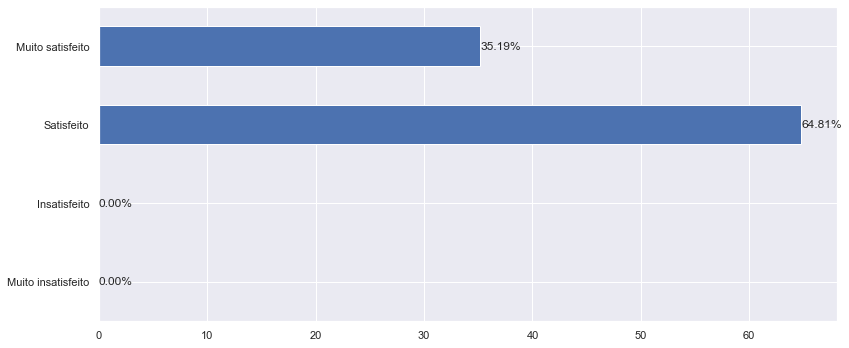

In [68]:
aux = df_secao_setic['q1034']
aux = aux.replace({'Muito insatisfeito': 'Muito satisfeito', 'Insatisfeito': 'Satisfeito'})

dictionary = {'Muito satisfeito': 0, 'Satisfeito': 0, 'Insatisfeito': 0, 'Muito insatisfeito': 0}
dados = pd.DataFrame.from_dict({**dictionary, **aux.value_counts().to_dict()}, orient='index')

ax = ((100*dados/aux.count())) \
    .reindex(index=['Muito insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito satisfeito']) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

ax.get_legend().set_visible(False)

plt.tight_layout()

#### Estatísticas

In [108]:
aux = df_secao_setic['q1034']
aux = aux.replace({'Muito insatisfeito': 'Muito satisfeito', 'Insatisfeito': 'Satisfeito'})
aux = aux.replace({'Muito satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito insatisfeito': 1})
aux.describe()

count    54.000000
mean      3.351852
std       0.482032
min       3.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       4.000000
Name: q1034, dtype: float64

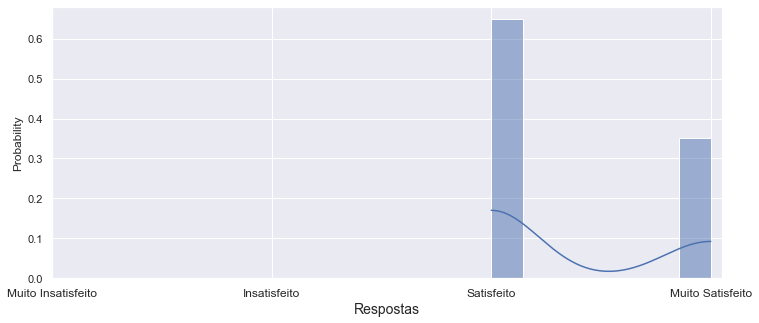

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
#sns.boxplot(x=aux, fill=False, showmeans=True, meanline=True, ax=ax)
sns.histplot(x=aux, ax=ax, stat='probability', kde=True)

plt.xlabel("Respostas", size=14)
ax.set_xticks(ticks=[1,2,3,4], labels=['Muito Insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito Satisfeito'], size=12)


### 1035. As boas práticas de TIC induzidas pelo Diretor Geral do SETIC (PRODERJ) aos órgãos setoriais ajudaram o Gestor de TI a lidar com seus problemas? 

In [140]:
df_secao_setic['q1035'].value_counts()

Sim, ajudaram bastante                                                       33
Sim, ajudaram de alguma forma                                                28
Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)     2
Não, realmente não ajudaram                                                   1
Não, aparentemente pioraram as coisas                                         1
Name: q1035, dtype: int64

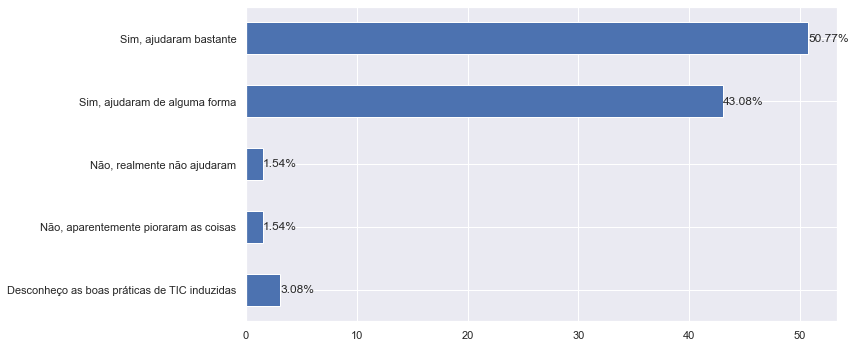

In [69]:
#1035. As boas práticas de TIC induzidas pelo Diretor Geral do SETIC (PRODERJ) aos órgãos setoriais ajudaram o
#Gestor de TI a lidar com seus problemas? 

#aux = df_secao_setic[df_secao_setic['q1035'] != 'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)']['q1035']
aux = df_secao_setic['q1035'].replace({'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)': 'Desconheço as boas práticas de TIC induzidas'})

ax = ((100*aux.value_counts()/aux.count())) \
    .reindex(index=['Desconheço as boas práticas de TIC induzidas', 'Não, aparentemente pioraram as coisas', 'Não, realmente não ajudaram', 'Sim, ajudaram de alguma forma', 'Sim, ajudaram bastante']) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()

#### Opiniões positivas acerca das boas práticas de TIC induzidas pelo Diretor Geral

In [142]:
df_secao_setic[
    (df_secao_setic['q1035'] == 'Sim, ajudaram bastante') | 
    (df_secao_setic['q1035'] == 'Sim, ajudaram de alguma forma')
].filter(regex='^q1035').sort_values(by='attribute_1')

,q1035,q1035raz
attribute_1,,
AGENERSA,"Sim, ajudaram bastante","Melhora o entendimento quanto ao objetivo estadual para a TIC, e ajuda nas escolhas tecnológicas. Os cursos são muito bons e ajudam a equipe de TI dos órgãos a se atualizar."
AGERIO,"Sim, ajudaram de alguma forma","Embora não subordinada às normativas do PRODERJ, a AgeRio as utiliza como referência de boas práticas para elaboração das próprias normas."
AGETRANSP,"Sim, ajudaram de alguma forma",Para a Gestão de TI as práticas são fundamentais até mesmo para o gerenciamento de riscos dos ativos e dos serviços. Embora não tenhamos documentações no âmbito da Agência essas boas práticas funcionam como diretrizes gerais para a gestão de TI da Autarquia.
CECIERJ,"Sim, ajudaram bastante",As comunicações realizadas colaboram e fortalecem nossas preocupações na formulação de conformidades.
CEHAB,"Sim, ajudaram bastante",O PRODERJ tem disponibilizado cursos técnicos eventos e foruns.
CENTRAL,"Sim, ajudaram bastante",O Proderj nos apoia prontamente dando suporte e consultoria quando necessário.
CEPERJ,"Sim, ajudaram bastante",As ARP otimizam os processos de contratação e padronizam as soluções contratadas.
CGE,"Sim, ajudaram bastante",Ajudaram a resolver
CODERTE,"Sim, ajudaram de alguma forma",Com a inclusão da academia proderj tem sido possível aumentar o conhecimento e poder agregar para a melhoria das boas práticas de TI dentro do órgão.


#### Opiniões negativas acerca das boas práticas de TIC induzidas pelo Diretor Geral

In [115]:
df_secao_setic[
    (df_secao_setic['q1035'] == 'Não, realmente não ajudaram') | 
    (df_secao_setic['q1035'] == 'Não, aparentemente pioraram as coisas')
].filter(regex='^q1035').sort_values(by='attribute_1')

,q1035,q1035raz
attribute_1,,
FSC,"Não, realmente não ajudaram",As normativas elaboradas pelo PRODERJ nem sempre se adequam à realidade limitada existente em todos os órgãos.
SEPM,"Não, aparentemente pioraram as coisas",NaN


#### Organizações que desconhecem as boas práticas induzidas pelo Diretor Geral

In [117]:
df_secao_setic[
    df_secao_setic['q1035'] == 'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)'
].filter(regex='q1035')

,q1035,q1035raz
attribute_1,,
CEASA,Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ),"Oficialmente, a área de TI não teve conhecimento de cursos técnicos, práticos e teóricos que viesse a orientar na implementação quanto às normas técnicas do PRODERJ."
FIA/RJ,Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ),"Por se tratar de nova gestão, ainda não houve a adoção das boas práticas."


#### Estatísticas

In [119]:
aux = df_secao_setic[df_secao_setic['q1035'] != 'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)']['q1035']
aux = aux.replace({'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1})
aux.describe()

count    63.000000
mean      3.476190
std       0.618457
min       1.000000
25%       3.000000
50%       4.000000
75%       4.000000
max       4.000000
Name: q1035, dtype: float64

Text(0.5, 0, 'Respostas')

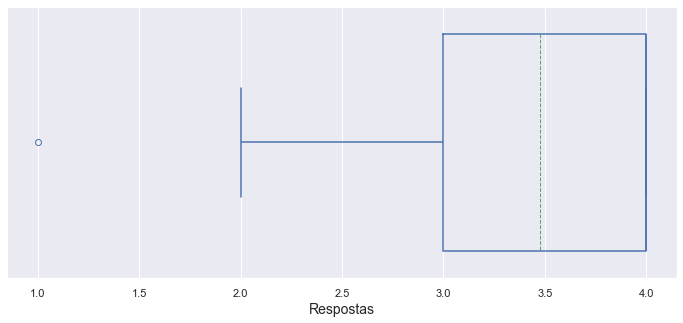

In [121]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
sns.boxplot(x=aux, fill=False, showmeans=True, meanline=True, ax=ax)
#sns.histplot(x=aux, ax=ax, stat='probability', kde=True)

plt.xlabel("Respostas", size=14)
#ax.set_xticks(ticks=[1,2,3,4], labels=['Não, aparentemente pioraram as coisas', 'Não, realmente não ajudaram', 'Sim, ajudaram de alguma forma', 'Sim, ajudaram bastante'], size=12)

### 1036. Como o Gestor de TI avalia os atos e normativos de TIC elaborados pelo Diretor Geral do SETIC (PRODERJ) para cumprimento dos órgãos do nível setorial.

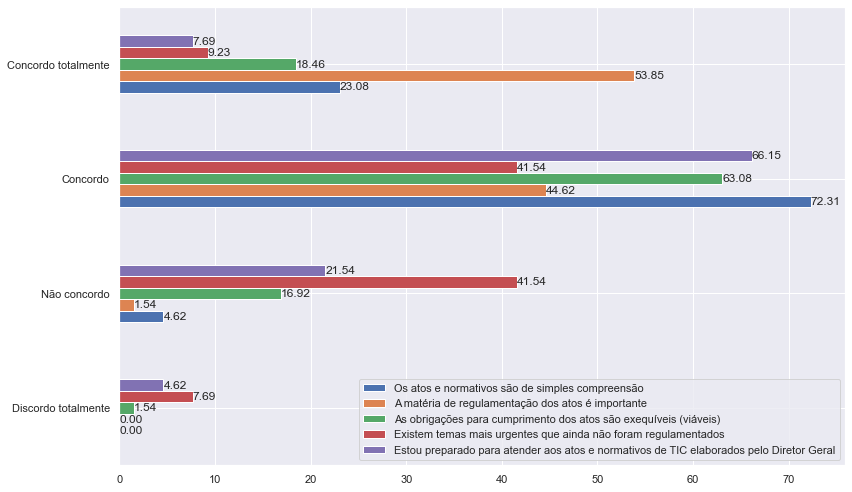

In [143]:
ax = (100*df_secao_setic.filter(regex='^q1036\[SQ').apply(pd.value_counts)/65) \
    .reindex(index=['Discordo totalmente', 'Não concordo', 'Concordo', 'Concordo totalmente']) \
    .plot.barh(figsize=(12, 7))

ax.legend([
    'Os atos e normativos são de simples compreensão', 
    'A matéria de regulamentação dos atos é importante', 
    'As obrigações para cumprimento dos atos são exequíveis (viáveis)', 
    'Existem temas mais urgentes que ainda não foram regulamentados',
    'Estou preparado para atender aos atos e normativos de TIC elaborados pelo Diretor Geral'
])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()

#### Avaliação quanto à forma

In [8]:
df_secao_setic['q1036[SQ001]'].value_counts()

Concordo               47
Concordo totalmente    15
Não concordo            3
Name: q1036[SQ001], dtype: int64

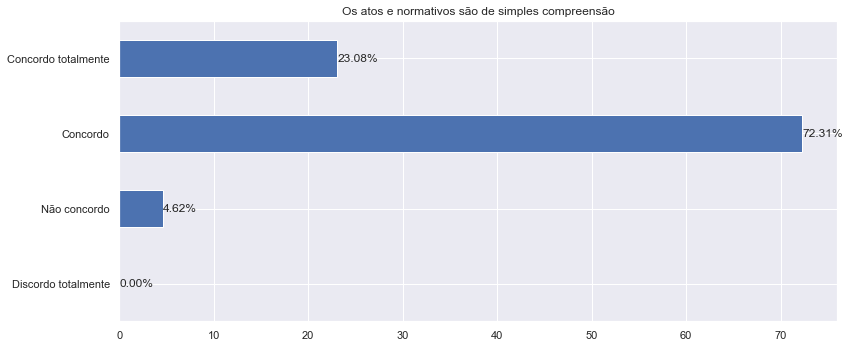

In [155]:
ax = (100*df_secao_setic.filter(regex='^q1036\[SQ001\]').apply(pd.value_counts)/65) \
    .reindex(index=['Discordo totalmente', 'Não concordo', 'Concordo', 'Concordo totalmente']) \
    .plot.barh(figsize=(12, 5), title='Os atos e normativos são de simples compreensão')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

ax.get_legend().set_visible(False)

plt.tight_layout()

#### Organizações que avaliaram os atos e normativos como de díficil compreensão

In [22]:
df_secao_setic[
    (df_secao_setic['q1036[SQ001]'] == 'Discordo totalmente') | 
    (df_secao_setic['q1036[SQ001]'] == 'Não concordo')
].filter(regex='^q1036r').sort_values(by='attribute_1').dropna()

,q1036raz
attribute_1,
ISP,"O teor de alguns atos normativos merecem esclarecimentos; regulamentar as questões relacionadas a TIC é importante; as obrigações para as execuções constantes nos atos nem sempre são realistas e não contemplam a realidade financeira de cada órgão e nem sua estrutura interna ou dimensão; temas como estruturação física poderiam ganhar prioridade por ser a base das demais ações em TIC; o atendimento aos atos normativos torna-se, na maioria das vezes, inviável, visto que nem sempre o ato contempla a realidade, além de exigir do gestor de TIC conhecimentos práticos sobre legislação específica."
RJPREV,"Embora as informações tenham sido encaminhadas, restou dúvidas quanto à obrigatoriedade desta Fundação de aderir às normas."


#### Avaliação quanto a relevância da temática

In [9]:
df_secao_setic[['q1036[SQ002]', 'q1036[SQ004]']].apply(pd.value_counts)

,q1036[SQ002],q1036[SQ004]
Concordo,29.0,27
Concordo totalmente,35.0,6
Discordo totalmente,NaN,5
Não concordo,1.0,27


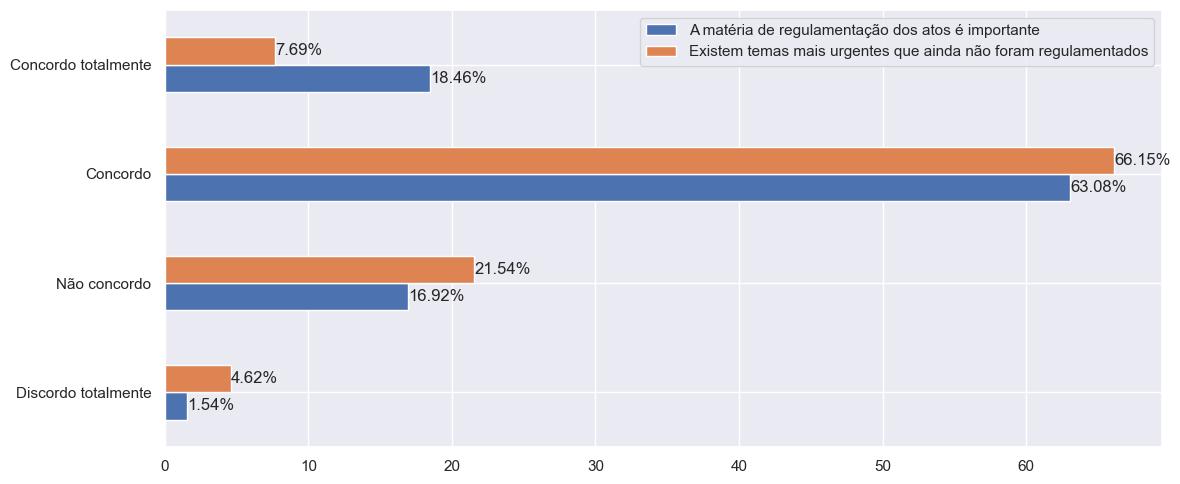

In [11]:
ax = (100*df_secao_setic[['q1036[SQ002]', 'q1036[SQ004]']].apply(pd.value_counts)/65) \
    .reindex(index=['Discordo totalmente', 'Não concordo', 'Concordo', 'Concordo totalmente']) \
    .plot.barh(figsize=(12, 5))

ax.legend([
    'A matéria de regulamentação dos atos é importante', 
    'Existem temas mais urgentes que ainda não foram regulamentados',
])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()

#### Organizações que avaliaram temas mais urgentes para serem regulamentados

In [18]:
df_secao_setic[
    (df_secao_setic['q1036[SQ004]'] == 'Concordo totalmente') | 
    (df_secao_setic['q1036[SQ004]'] == 'Concordo')
].filter(regex='^q1036ra').sort_values(by='attribute_1').dropna()

,q1036raz
attribute_1,
AGERIO,Consideramos as normas do PRODERJ bastante bem escritas e as utilizamos como referência para elaboração das nossas próprias normas.
CEASA,"Lamentamos informar que não foi possível implementar as medidas necessárias à criação de uma estrutura própria de TIC, pessoal e equipamentos, conforme indicações contidas no bojo do Ofício nº 2710/23 - AUD/SGE/GAP, de 14 de agosto de 2023 (57950885), pelas razões não apenas aquelas já apresentadas pela nossa Diretora-Presidente (documento SEI nº 59372832), em sede do SEI-020004/000723/2023, mas também pelas questões que serão pormenorizadas abaixo.\n\n\tDe fato, conforme previsão que consta do próprio Ofício supra referido, a Companhia não aderiu integralmente aos ditames previstos no Anexo C da Portaria PRODERJ/PRE nº 825, de 26 de fevereiro de 2021.\n\n\tComo é sabido, a atual Diretoria Executiva da Companhia tomou posse em 10 de abril de 2019, sendo complementada sua composição total somente no ano de 2021, sendo integrado o Diretor de Administração.\n\n\tDesde o ano de 2017, em todo o Estado do Rio de Janeiro há profundos impedimentos e limitação na gestão, principalmente, como forma de se reduzir o gasto público, como consequência pela adesão ao Regime de Recuperação Fiscal trazido ao Ordenamento Jurídico pela Lei Complementar nº 159, de 19 de maio de 2017, inclusive, com as alterações introduzidas pela Lei Complementar nº 178, de 13 de janeiro de 2021.\n\n\tTambém é de conhecimento notório, que o artigo 8º da referida norma legal, nos impede inclusive de realizar concurso público, exceto, se for para o preenchimento de vacância e mediante apresentação de Plano de Compensação. De fato, esta Companhia assim procedeu e em diversos pleitos de autorização para realização de concursos, sempre mereceu uma negativa como resposta, em que pese CEASA-RJ nunca, em toda a sua história, ter realizado um concurso público.\n\n\tNossos empregados são sexagenários em grande maioria, havendo até mesmo os que ultrapassam os oitenta anos de idade, portanto, colaboradores em adiantado estágio da vida, afora poucas exceções, sem atualização, capacitação ou qualificação técnica, principalmente, para as novas tecnologias e às novas ferramentas.\n\n\tAssim, com nossa própria equipe, torna-se inviável estruturar-se um plano estratégico apenas para atender as necessidades em TIC, pois necessitamos de advogados, contadores, engenheiros agrônomos, ou seja: técnicos nas mais variadas atividades, em um universo pouco numeroso.\n\n\tPelo exposto, colocamo-nos a disposição para o esclarecimento de eventuais dúvidas noveis."
CEPERJ,"Para a administração pública ainda existe muitos desafios, principalmente a fornecedores ao serviço público, existe poucos, portanto o preço e a diversidade de soluções são muitas vezes incompatíveis com a realidade do órgão."
CGE,Pq entendemos a importância da regulamentação de forma a tornar mais eficientes os procedimentos
CODERTE,"Nem sempre é possível atender dentro do prazo estipulado pelo PRODERJ, devido à realidade de cada órgão ter suas estruturas, processos e metodologias internas de trabalho, logo, isso pode afetar na entrega dos resultados dentro dos prazos. A insuficiência financeira para os órgãos também contam muito para a melhoria em diversos segmentos de TI."
CODIN,"Havendo maior interação entre os órgãos, as disposições seriam melhor atendidas."
DEGASE,"A demanda excessiva específica de TIC, aliada à falta de mão-de-obra especializada impedem uma maior abrangência"
EMATER,"O recebimento de orientações do PRODERJ é importante para conformidade, regras do negócio."
FAETEC,Como sou gestor de TI avalio os atos e normativos de TIC elaborados pelo Diretor Geral do SETIC (PRODERJ) tenho ciencia que o cumprimento das determinações do órgão é fundamenta a todo nível setorial da minha instituição.


#### Avaliação quanto a exequibilidade dos órgãos do nível setorial

In [12]:
df_secao_setic[['q1036[SQ003]', 'q1036[SQ005]']].apply(pd.value_counts)

,q1036[SQ003],q1036[SQ005]
Concordo,41,43
Concordo totalmente,12,5
Discordo totalmente,1,3
Não concordo,11,14


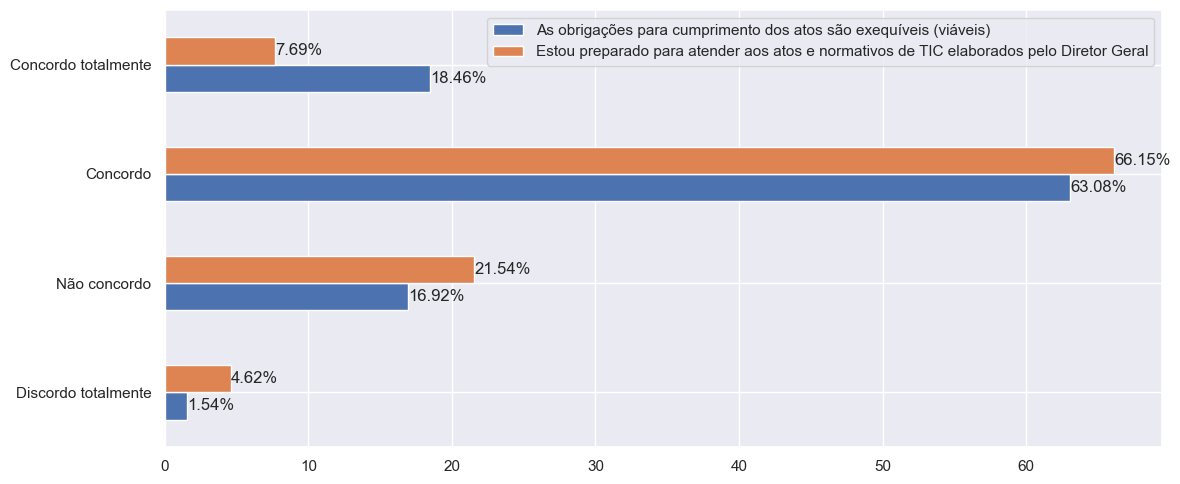

In [62]:
ax = (100*df_secao_setic[['q1036[SQ003]', 'q1036[SQ005]']].apply(pd.value_counts)/65) \
    .reindex(index=['Discordo totalmente', 'Não concordo', 'Concordo', 'Concordo totalmente']) \
    .plot.barh(figsize=(12, 5))

ax.legend([
    'As obrigações para cumprimento dos atos são exequíveis (viáveis)', 
    'Estou preparado para atender aos atos e normativos de TIC elaborados pelo Diretor Geral'
])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()

#### Organizações que avaliaram não estar preparadas para atender aos normativos do DG

In [16]:
df_secao_setic[
    (df_secao_setic['q1036[SQ005]'] == 'Não concordo') | 
    (df_secao_setic['q1036[SQ005]'] == 'Discordo totalmente')
].filter(regex='^q1036ra').sort_values(by='attribute_1')

,q1036raz
attribute_1,
AGENERSA,"Quanto ao cumprimento das obrigações, os órgãos ainda tem bastante dificuldade para atende-los, muito pela equipe reduzida."
AGETRANSP,Ainda que esta Autarquia não tenha documentações formais as diretrizes são importantes para orientar a Gestão de TI da Entidade.
CECIERJ,"Basicamente algumas das obrigações dependem da colaboração interna, continuidade dos processos de adequação, recursos humanos e tempo. Contudo a fundação está passando por processos de ajustes, implementando instrumentos de gestão: Comissão PEDTIC SEI-260004/002095/2023; Pendências de Compliance de TIC SEI-260004/001751/2023; Compliance de Projetos de Sistemas de TIC SEI-260004/001280/2023."
CEPERJ,"Para a administração pública ainda existe muitos desafios, principalmente a fornecedores ao serviço público, existe poucos, portanto o preço e a diversidade de soluções são muitas vezes incompatíveis com a realidade do órgão."
CODERTE,"Nem sempre é possível atender dentro do prazo estipulado pelo PRODERJ, devido à realidade de cada órgão ter suas estruturas, processos e metodologias internas de trabalho, logo, isso pode afetar na entrega dos resultados dentro dos prazos. A insuficiência financeira para os órgãos também contam muito para a melhoria em diversos segmentos de TI."
DER/RJ,"Ainda me falta especialização, principalmente, na área de segurança da informação."
FIA/RJ,"Entende-se a importância da regulamentação, mas ainda não houve total adequação do setor às normativas por se tratar de nova gestão."
FLXIII,Não se aplica
FS,Sem Observações a Realizar


#### Considerações acerca dos normativos do Diretor Geral

In [23]:
df_secao_setic.filter(regex='^q1036ra').dropna().sort_values(by='attribute_1')

,q1036raz
attribute_1,
AGENERSA,"Quanto ao cumprimento das obrigações, os órgãos ainda tem bastante dificuldade para atende-los, muito pela equipe reduzida."
AGERIO,Consideramos as normas do PRODERJ bastante bem escritas e as utilizamos como referência para elaboração das nossas próprias normas.
AGETRANSP,Ainda que esta Autarquia não tenha documentações formais as diretrizes são importantes para orientar a Gestão de TI da Entidade.
CEASA,"Lamentamos informar que não foi possível implementar as medidas necessárias à criação de uma estrutura própria de TIC, pessoal e equipamentos, conforme indicações contidas no bojo do Ofício nº 2710/23 - AUD/SGE/GAP, de 14 de agosto de 2023 (57950885), pelas razões não apenas aquelas já apresentadas pela nossa Diretora-Presidente (documento SEI nº 59372832), em sede do SEI-020004/000723/2023, mas também pelas questões que serão pormenorizadas abaixo.\n\n\tDe fato, conforme previsão que consta do próprio Ofício supra referido, a Companhia não aderiu integralmente aos ditames previstos no Anexo C da Portaria PRODERJ/PRE nº 825, de 26 de fevereiro de 2021.\n\n\tComo é sabido, a atual Diretoria Executiva da Companhia tomou posse em 10 de abril de 2019, sendo complementada sua composição total somente no ano de 2021, sendo integrado o Diretor de Administração.\n\n\tDesde o ano de 2017, em todo o Estado do Rio de Janeiro há profundos impedimentos e limitação na gestão, principalmente, como forma de se reduzir o gasto público, como consequência pela adesão ao Regime de Recuperação Fiscal trazido ao Ordenamento Jurídico pela Lei Complementar nº 159, de 19 de maio de 2017, inclusive, com as alterações introduzidas pela Lei Complementar nº 178, de 13 de janeiro de 2021.\n\n\tTambém é de conhecimento notório, que o artigo 8º da referida norma legal, nos impede inclusive de realizar concurso público, exceto, se for para o preenchimento de vacância e mediante apresentação de Plano de Compensação. De fato, esta Companhia assim procedeu e em diversos pleitos de autorização para realização de concursos, sempre mereceu uma negativa como resposta, em que pese CEASA-RJ nunca, em toda a sua história, ter realizado um concurso público.\n\n\tNossos empregados são sexagenários em grande maioria, havendo até mesmo os que ultrapassam os oitenta anos de idade, portanto, colaboradores em adiantado estágio da vida, afora poucas exceções, sem atualização, capacitação ou qualificação técnica, principalmente, para as novas tecnologias e às novas ferramentas.\n\n\tAssim, com nossa própria equipe, torna-se inviável estruturar-se um plano estratégico apenas para atender as necessidades em TIC, pois necessitamos de advogados, contadores, engenheiros agrônomos, ou seja: técnicos nas mais variadas atividades, em um universo pouco numeroso.\n\n\tPelo exposto, colocamo-nos a disposição para o esclarecimento de eventuais dúvidas noveis."
CECIERJ,"Basicamente algumas das obrigações dependem da colaboração interna, continuidade dos processos de adequação, recursos humanos e tempo. Contudo a fundação está passando por processos de ajustes, implementando instrumentos de gestão: Comissão PEDTIC SEI-260004/002095/2023; Pendências de Compliance de TIC SEI-260004/001751/2023; Compliance de Projetos de Sistemas de TIC SEI-260004/001280/2023."
CEHAB,"As orientações visam a proteção a dados, melhores técnicas de processamentos,"
CENTRAL,O Proderj nos apoia prontamente dando suporte e consultoria quando necessário.
CEPERJ,"Para a administração pública ainda existe muitos desafios, principalmente a fornecedores ao serviço público, existe poucos, portanto o preço e a diversidade de soluções são muitas vezes incompatíveis com a realidade do órgão."
CGE,Pq entendemos a importância da regulamentação de forma a tornar mais eficientes os procedimentos


#### Visão geral

In [12]:
#1036. Como o Gestor de TI avalia os atos e normativos de TIC elaborados pelo Diretor Geral do SETIC (PRODERJ)
#para cumprimento dos órgãos do nível setorial.

aux = df_secao_setic.filter(regex='q1036').replace({
    'Concordo totalmente': 4, 'Concordo': 3, 'Não concordo': 2, 'Discordo totalmente': 1
})
aux.describe()

,q1036[SQ001],q1036[SQ002],q1036[SQ003],q1036[SQ004],q1036[SQ005]
count,65.000000,65.000000,65.000000,65.000000,65.000000
mean,3.184615,3.523077,2.984615,2.523077,2.769231
std,0.496623,0.533494,0.649334,0.772732,0.655964
min,2.000000,2.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000
50%,3.000000,4.000000,3.000000,3.000000,3.000000
75%,3.000000,4.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000


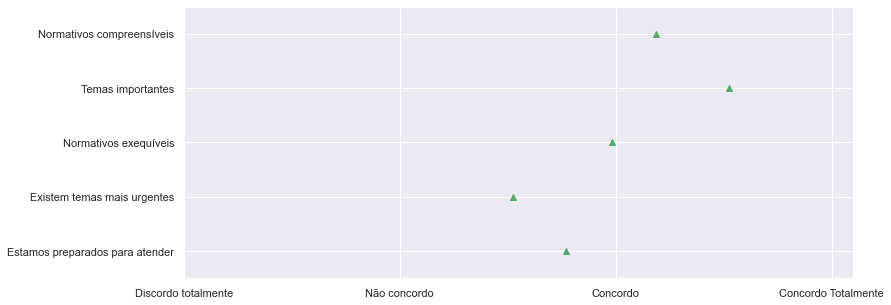

In [13]:
ax = aux.rename(columns={
    'q1036[SQ001]': 'Normativos compreensíveis', 
    'q1036[SQ002]': 'Temas importantes',
    'q1036[SQ003]': 'Normativos exequíveis',
    'q1036[SQ004]': 'Existem temas mais urgentes',
    'q1036[SQ005]': 'Estamos preparados para atender',
}) \
    .iloc[:,::-1] \
    .boxplot(showmeans=True, vert=False, showcaps=False, showbox=False, showfliers=False, whis=0, medianprops=dict(linewidth=.001), figsize=(12, 5))
#ax = aux.boxplot(showmeans=True, vert=False, figsize=(12, 5))

ax.set_xticks(ticks=[1,2,3,4], labels=['Discordo totalmente', 'Não concordo', 'Concordo', 'Concordo Totalmente'])


### 1037. Para o Gestor de TI, a atuação do Diretor Geral do SETIC (PRODERJ), como integrador de soluções de TIC, atende as necessidades de TIC da organização.


In [60]:
df_secao_setic['q1037'].value_counts()

Sim, ajudaram de alguma forma            40
Sim, ajudaram bastante                   21
Não, realmente não ajudaram               3
Não, aparentemente pioraram as coisas     1
Name: q1037, dtype: int64

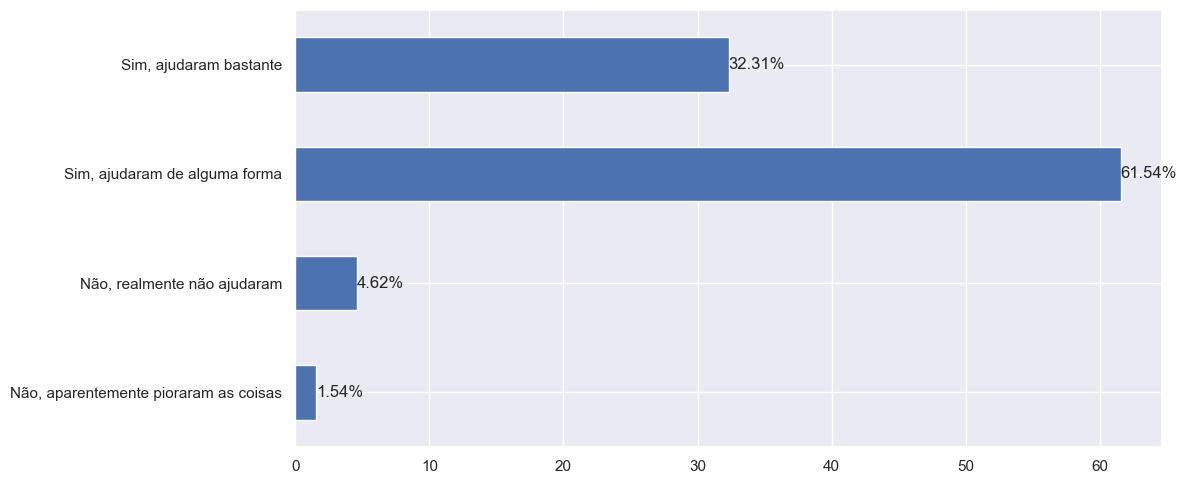

In [63]:
#1037. Para o Gestor de TI, a atuação do Diretor Geral do SETIC (PRODERJ), como integrador de soluções de TIC,
#atende as necessidades de TIC da organização.

ax = ((100*df_secao_setic['q1037'].value_counts()/df_secao_setic['q1037'].count())) \
    .reindex(index=['Não, aparentemente pioraram as coisas', 'Não, realmente não ajudaram', 'Sim, ajudaram de alguma forma', 'Sim, ajudaram bastante']) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()

In [15]:
df_secao_setic.filter(regex='q1037ra').dropna().sort_values(by='attribute_1')

,q1037raz
attribute_1,
AGENERSA,"As ARP centralizadas no Órgão gestor de TIC auxiliam muito as contratações a serem realizadas pelos órgãos, facilitam a integração entre as soluções."
AGERIO,"Não somos subordinados ao PRODERJ, mas utilizamos bastante os treinamentos oferecidos e aderimos a diversas Atas de Registro de Preço do órgão."
AGETRANSP,Esta Agência Reguladora vem envidado esforços para estreitar os laços com o PRODERJ visando o melhor aproveitamento das normativas por eles estabelecidas.
CEASA,Quando esta Unidade necessitou de uma integração junto ao TI do PRODERJ fomos atendidos.
CECIERJ,"Como exemplo positivo, a fundação realizou um estudo sobre a possibilidade de aquisição de licenças de softwares para servidores e recebemos um excelente auxílio e apoio instrucional. Como exemplo negativo no processo de aquisição de antivírus SEI-260004/001294/2021, a análise demorou sob justificativa de uma ATA em confecção que só veio a sair 1 ano depois, o que nos deixou temporariamente descobertos porque a alta gestão não ficou confortável em dar prosseguimento na contratação sem o aval explícito para tal, além disso a solução era desvantajosa economicamente a implantada na organização. Deve-se ter o cuidado com a usurpação das atribuições e autonomia das organizações e de seus técnicos."
CEHAB,"Através das ATAs, atende plenamente as necessidades dos Órgãos."
CENTRAL,O Proderj nos apoia prontamente dando suporte e consultoria quando necessário.
CEPERJ,"Cada órgão possui sua especificidade, logo, atender em completude é inexequível. Contudo, as ARP são de extrema importância."
CGE,A divulgação dos PLS pode ser melhorada


#### Opiniões positivas acerca da atuação do Diretor Geral como integrador de soluções de TIC

In [65]:
df_secao_setic[
    (df_secao_setic['q1037'] == 'Sim, ajudaram bastante') | 
    (df_secao_setic['q1037'] == 'Sim, ajudaram de alguma forma')
].filter(regex='q1037').dropna().sort_values(by='attribute_1')

,q1037,q1037raz
attribute_1,,
AGENERSA,"Sim, ajudaram bastante","As ARP centralizadas no Órgão gestor de TIC auxiliam muito as contratações a serem realizadas pelos órgãos, facilitam a integração entre as soluções."
AGERIO,"Sim, ajudaram de alguma forma","Não somos subordinados ao PRODERJ, mas utilizamos bastante os treinamentos oferecidos e aderimos a diversas Atas de Registro de Preço do órgão."
AGETRANSP,"Sim, ajudaram de alguma forma",Esta Agência Reguladora vem envidado esforços para estreitar os laços com o PRODERJ visando o melhor aproveitamento das normativas por eles estabelecidas.
CEASA,"Sim, ajudaram bastante",Quando esta Unidade necessitou de uma integração junto ao TI do PRODERJ fomos atendidos.
CECIERJ,"Sim, ajudaram de alguma forma","Como exemplo positivo, a fundação realizou um estudo sobre a possibilidade de aquisição de licenças de softwares para servidores e recebemos um excelente auxílio e apoio instrucional. Como exemplo negativo no processo de aquisição de antivírus SEI-260004/001294/2021, a análise demorou sob justificativa de uma ATA em confecção que só veio a sair 1 ano depois, o que nos deixou temporariamente descobertos porque a alta gestão não ficou confortável em dar prosseguimento na contratação sem o aval explícito para tal, além disso a solução era desvantajosa economicamente a implantada na organização. Deve-se ter o cuidado com a usurpação das atribuições e autonomia das organizações e de seus técnicos."
CEHAB,"Sim, ajudaram de alguma forma","Através das ATAs, atende plenamente as necessidades dos Órgãos."
CENTRAL,"Sim, ajudaram bastante",O Proderj nos apoia prontamente dando suporte e consultoria quando necessário.
CEPERJ,"Sim, ajudaram de alguma forma","Cada órgão possui sua especificidade, logo, atender em completude é inexequível. Contudo, as ARP são de extrema importância."
CGE,"Sim, ajudaram de alguma forma",A divulgação dos PLS pode ser melhorada


#### Opiniões negativas acerca da atuação do Diretor Geral como integrador de soluções de TIC

In [66]:
df_secao_setic[
    (df_secao_setic['q1037'] == 'Não, realmente não ajudaram') | 
    (df_secao_setic['q1037'] == 'Não, aparentemente pioraram as coisas')
].filter(regex='q1037').dropna().sort_values(by='attribute_1')

,q1037,q1037raz
attribute_1,,
FSC,"Não, realmente não ajudaram",As normativas elaboradas pelo PRODERJ nem sempre se adequam à realidade limitada existente em todos os órgãos.
SEDEC,"Não, aparentemente pioraram as coisas","Nosso órgão possui muitas especificidades, ficando difícil de ser incluído em uma contratação generalizada. Recentemente tivemos de aderir a uma contratação que não atendia nossas necessidades e nos gerou diversos problemas."
UERJ,"Não, realmente não ajudaram","Apesar de conhecer o teor do Decreto Estadual nº 47.278/2020, A DGTI entende que tanto o Decreto quanto os atos normativos não são\naplicáveis à UERJ, tendo em vista a Autonomia didático-científica, administrativa e de gestão\nfinanceira e patrimonial, concedida nos arts. 207 da Constituição da República Federativa do Brasil e 309 da\nConstituição do Estado do Rio de Janeiro. Por este motivo, a UERJ adotou a postura de adequar-se parcialmente,\nlevando em considerando que regulará internamente a temática."


#### Estatísticas

In [16]:
aux = df_secao_setic['q1037']
aux = aux.replace({'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1})
aux.describe()

count    65.000000
mean      3.246154
std       0.613157
min       1.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       4.000000
Name: q1037, dtype: float64

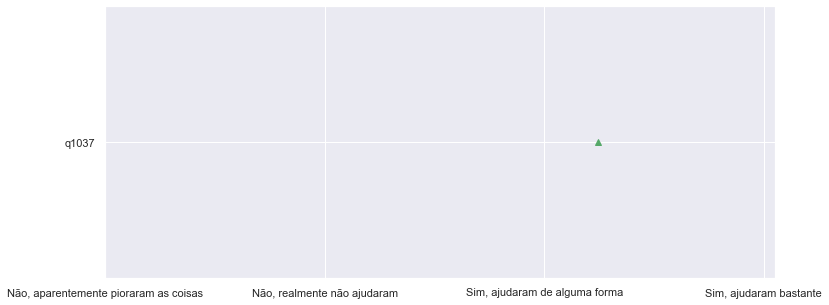

In [18]:
ax = aux.plot.box(showmeans=True, vert=False, showcaps=False, showbox=False, showfliers=False, whis=0, medianprops=dict(linewidth=.001), figsize=(12, 5))
ax.set_xticks(ticks=[1,2,3,4], labels=['Não, aparentemente pioraram as coisas', 'Não, realmente não ajudaram', 'Sim, ajudaram de alguma forma', 'Sim, ajudaram bastante'])

### 1038. Considerando os meios de comunicação disponíveis, quando necessário, o atendimento prestado pelo Diretor Geral (PRODERJ) ao Gestor de TI supriu as expectativas.


In [19]:
df_secao_setic['q1038'].value_counts()

Concordo               38
Concordo totalmente    24
Discordo                3
Name: q1038, dtype: int64

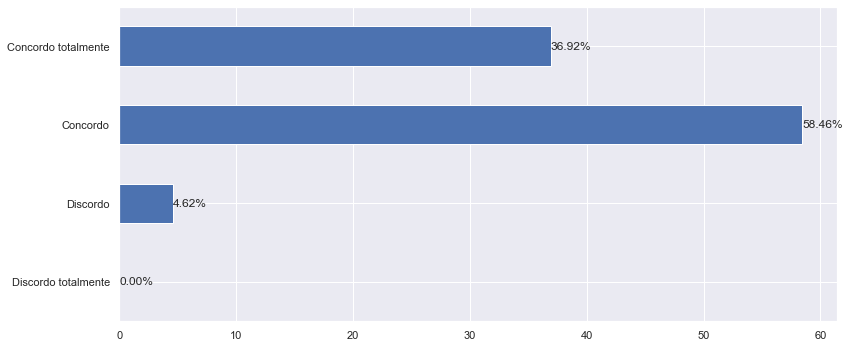

In [21]:
#1038. Considerando os meios de comunicação disponíveis, quando necessário, o atendimento prestado pelo
#Diretor Geral (PRODERJ) ao Gestor de TI supriu as expectativas.

dictionary = {'Concordo totalmente': 0, 'Concordo': 0, 'Discordo': 0, 'Discordo totalmente': 0}
dados = pd.DataFrame.from_dict({**dictionary, **df_secao_setic['q1038'].value_counts().to_dict()}, orient='index')

ax = ((100*dados/df_secao_setic['q1038'].count())) \
    .reindex(index=['Discordo totalmente', 'Discordo', 'Concordo', 'Concordo totalmente']) \
    .plot.barh(figsize=(12, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

ax.get_legend().set_visible(False)

plt.tight_layout()

In [29]:
df_secao_setic.filter(regex='q1038r').dropna().sort_values(by='attribute_1')

,q1038raz
attribute_1,
AGENERSA,"Sim, a comunicação tem sido satisfatória. Apenas para as ARP, acredito que deveriam melhorar, comunicar com antecedência."
AGERIO,O PRODERJ busca manter contato através de diferentes canais e pontos focais com a instituição. Não temos dificuldade em entrar em contato com o órgão.
AGETRANSP,Com a nova gestão da Agência Reguladora estamos buscando maior proximidade com a direção geral do PRODERJ para que venhamos normatizar nossas práticas quanto à gestão de TI. Anteriormente não havia esforços mútuos para o estreitamento do relacionamento entre a AGETRANSP e o PRODERJ.
CEASA,"Quando esta Unidade necessitou de atendimento por grupos de mensagens na plataforma Whatsapp, lista de e-mails, comunicação institucional por ofícios e a Plataforma do AtendeRJ (Central de Atendimento), fomos atendidos."
CECIERJ,Sempre que precisamos encontramos os canais de atendimento.
CEHAB,"Grupo de mensagens, e-mails, ATENDRJ e Telefones."
CENTRAL,"Recebemos suporte via todos os meios digitais, inclusive telefônico."
CEPERJ,O grupo de whatsapp e os e-mails markting do PRODERJ ajudam bastante na interação entre órgãos e PRODERJ.
CGE,A comunicação foi eficiente


#### Opiniões positivas acerca do atendimento do Diretor Geral suprir as expectativas

In [28]:
df_secao_setic[
    (df_secao_setic['q1038'] == 'Concordo totalmente') | 
    (df_secao_setic['q1038'] == 'Concordo')
].filter(regex='q1038r').dropna().sort_values(by='attribute_1')

,q1038raz
attribute_1,
AGENERSA,"Sim, a comunicação tem sido satisfatória. Apenas para as ARP, acredito que deveriam melhorar, comunicar com antecedência."
AGERIO,O PRODERJ busca manter contato através de diferentes canais e pontos focais com a instituição. Não temos dificuldade em entrar em contato com o órgão.
CEASA,"Quando esta Unidade necessitou de atendimento por grupos de mensagens na plataforma Whatsapp, lista de e-mails, comunicação institucional por ofícios e a Plataforma do AtendeRJ (Central de Atendimento), fomos atendidos."
CECIERJ,Sempre que precisamos encontramos os canais de atendimento.
CEHAB,"Grupo de mensagens, e-mails, ATENDRJ e Telefones."
CENTRAL,"Recebemos suporte via todos os meios digitais, inclusive telefônico."
CEPERJ,O grupo de whatsapp e os e-mails markting do PRODERJ ajudam bastante na interação entre órgãos e PRODERJ.
CGE,A comunicação foi eficiente
CODERTE,"A plataforma WhatsApp, lista de e-mails, comunicação institucional por ofícios e a Plataforma do AtendeRJ (Central de Atendimento) tem contribuído muito na melhoria da comunicação e isso nos respalda, pois temos um ciclo de vida naquilo que foi solicitado e em grande parte tudo documentado."


#### Opiniões negativas acerca do atendimento do Diretor Geral suprir as expectativas

In [23]:
df_secao_setic[
    (df_secao_setic['q1038'] == 'Discordo') | 
    (df_secao_setic['q1038'] == 'Discordo totalmente')
].filter(regex='q1038').dropna().sort_values(by='attribute_1')

,q1038,q1038raz
attribute_1,,
AGETRANSP,Discordo,Com a nova gestão da Agência Reguladora estamos buscando maior proximidade com a direção geral do PRODERJ para que venhamos normatizar nossas práticas quanto à gestão de TI. Anteriormente não havia esforços mútuos para o estreitamento do relacionamento entre a AGETRANSP e o PRODERJ.
SEDEC,Discordo,"Apesar do nosso contato com o PRODERJ ser facilitado pelos meios informais, nossa comunicação por meio formal (SEI-RJ) sempre foi muito difícil e demorada, por muitas vezes atrasando nossos processos internos."


#### Estatísticas

In [26]:
aux = df_secao_setic.filter(regex='q1038$').replace({
    'Concordo totalmente': 4, 'Concordo': 3, 'Discordo': 2, 'Discordo totalmente': 1
})
aux.describe()

,q1038
count,65.000000
mean,3.323077
std,0.562019
min,2.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,4.000000


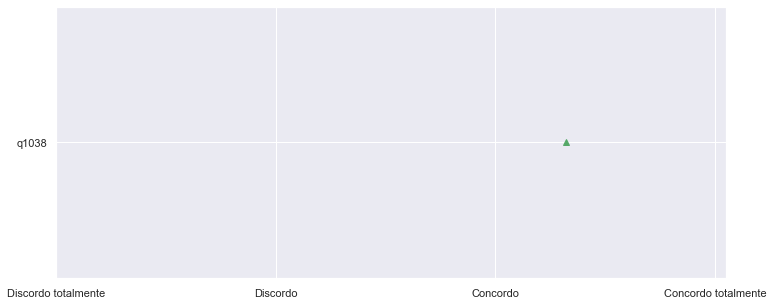

In [27]:
ax = aux.plot.box(showmeans=True, vert=False, showcaps=False, showbox=False, showfliers=False, whis=0, medianprops=dict(linewidth=.001), figsize=(12, 5))
ax.set_xticks(ticks=[1,2,3,4], labels=['Discordo totalmente', 'Discordo', 'Concordo', 'Concordo totalmente'])

# Quadro de questões

In [75]:
import numpy as np
import itertools

df_questoes_setic = df_secao_setic[
    ['q1032', 'q1034', 'q1035', 'q1036[SQ001]','q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ004]', 'q1036[SQ005]', 'q1037', 'q1038']
]
df_questoes_setic['q1034'].replace({'Muito insatisfeito': 'Muito satisfeito', 'Insatisfeito': 'Satisfeito'}, inplace=True)

df_questoes_setic = df_questoes_setic.replace({
    'Muito Satisfeito': 4, 'Muito satisfeito': 4, 'Satisfeito': 3, 'Insatisfeito': 2, 'Muito Insatisfeito': 1, 'Muito insatisfeito': 1,
    'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1,
    'Concordo totalmente': 4, 'Concordo': 3, 'Não concordo': 2, 'Discordo totalmente': 1, 'Discordo': 2,
    'Sim, ajudaram bastante': 4, 'Sim, ajudaram de alguma forma': 3, 'Não, realmente não ajudaram': 2, 'Não, aparentemente pioraram as coisas': 1,
    'Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ)': np.nan
})


C:\Users\augustocba\AppData\Local\Temp\ipykernel_11184\2686221269.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_questoes_setic['q1034'].replace({'Muito insatisfeito': 'Muito satisfeito', 'Insatisfeito': 'Satisfeito'}, inplace=True)


In [180]:
df_questoes_setic[['q1032', 'q1034', 'q1035', 'q1036[SQ001]','q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037', 'q1038']].describe()

,q1032,q1034,q1035,q1036[SQ001],q1036[SQ002],q1036[SQ003],q1036[SQ005],q1037,q1038
count,59.000000,54.000000,63.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,3.271186,3.351852,3.476190,3.184615,3.523077,2.984615,2.769231,3.246154,3.323077
std,0.485319,0.482032,0.618457,0.496623,0.533494,0.649334,0.655964,0.613157,0.562019
min,2.000000,3.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000
25%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,3.000000,4.000000,4.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


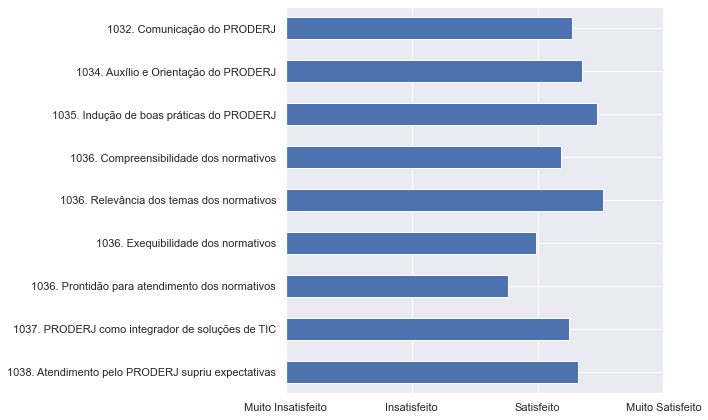

In [186]:
ax = df_questoes_setic[['q1032', 'q1034', 'q1035', 'q1036[SQ001]','q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037', 'q1038']]\
    .describe().loc['mean', ::-1] \
    .rename(index={
        'q1032':        '1032. Comunicação do PRODERJ',
        'q1034':        '1034. Auxílio e Orientação do PRODERJ',
        'q1035':        '1035. Indução de boas práticas do PRODERJ',
        'q1036[SQ001]': '1036. Compreensibilidade dos normativos',
        'q1036[SQ002]': '1036. Relevância dos temas dos normativos',
        'q1036[SQ003]': '1036. Exequibilidade dos normativos',
        'q1036[SQ004]': '1036. Omissão Temas urgentes pendentes',
        'q1036[SQ005]': '1036. Prontidão para atendimento dos normativos',
        'q1037':        '1037. PRODERJ como integrador de soluções de TIC',
        'q1038':        '1038. Atendimento pelo PRODERJ supriu expectativas',
    }).plot.barh(figsize=(10, 6)) \
    
ax.set_xticks(ticks=[1,2,3,4], labels=['Muito Insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito Satisfeito'])
ax.set_xlim([1,4])

plt.tight_layout()

<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>
<BarContainer object of 10 artists>


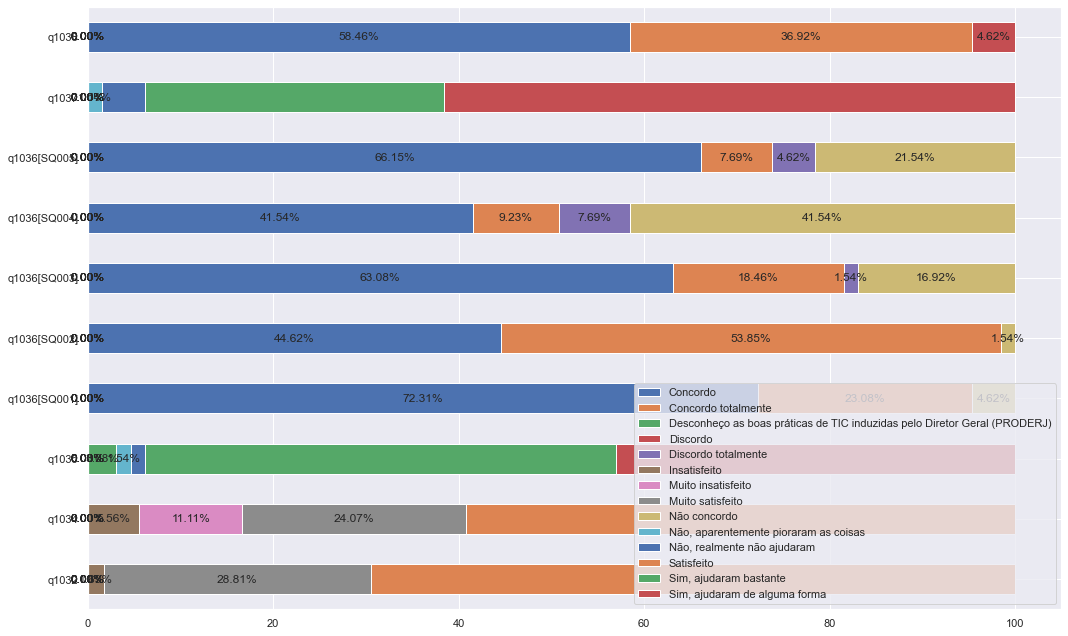

In [164]:
aux = df_secao_setic[['q1032', 'q1034', 'q1035', 'q1036[SQ001]','q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ004]', 'q1036[SQ005]', 'q1037', 'q1038']]
ax = (100*aux.replace({
    'Muito Satisfeito': 'Muito satisfeito', 
    'Muito Insatisfeito': 'Muito insatisfeito'
})\
.apply(pd.value_counts) / aux.apply(pd.value_counts).sum())\
.T.plot.barh(stacked=True, figsize=(15,9))

for container, col in zip(ax.containers, aux.columns):
    print(container)
    ax.bar_label(container, label_type='center', fmt='%.2f%%')

#ax.get_legend().set_visible(False)

plt.tight_layout()

In [161]:
aux = df_secao_setic[['q1032', 'q1034', 'q1035', 'q1036[SQ001]','q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ004]', 'q1036[SQ005]', 'q1037', 'q1038']]
aux.replace({
    'Muito Satisfeito': 'Muito satisfeito', 
    'Muito Insatisfeito': 'Muito insatisfeito'
})\
.apply(pd.value_counts) / aux.apply(pd.value_counts).sum()

,q1032,q1034,q1035,q1036[SQ001],q1036[SQ002],q1036[SQ003],q1036[SQ004],q1036[SQ005],q1037,q1038
Concordo,NaN,NaN,NaN,0.723077,0.446154,0.630769,0.415385,0.661538,NaN,0.584615
Concordo totalmente,NaN,NaN,NaN,0.230769,0.538462,0.184615,0.092308,0.076923,NaN,0.369231
Desconheço as boas práticas de TIC induzidas pelo Diretor Geral (PRODERJ),NaN,NaN,0.030769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Discordo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046154
Discordo totalmente,NaN,NaN,NaN,NaN,NaN,0.015385,0.076923,0.046154,NaN,NaN
Insatisfeito,0.016949,0.055556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Muito insatisfeito,NaN,0.111111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Muito satisfeito,0.288136,0.240741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Não concordo,NaN,NaN,NaN,0.046154,0.015385,0.169231,0.415385,0.215385,NaN,NaN
"Não, aparentemente pioraram as coisas",NaN,NaN,0.015385,NaN,NaN,NaN,NaN,NaN,0.015385,NaN


(-2.0, 2.0)

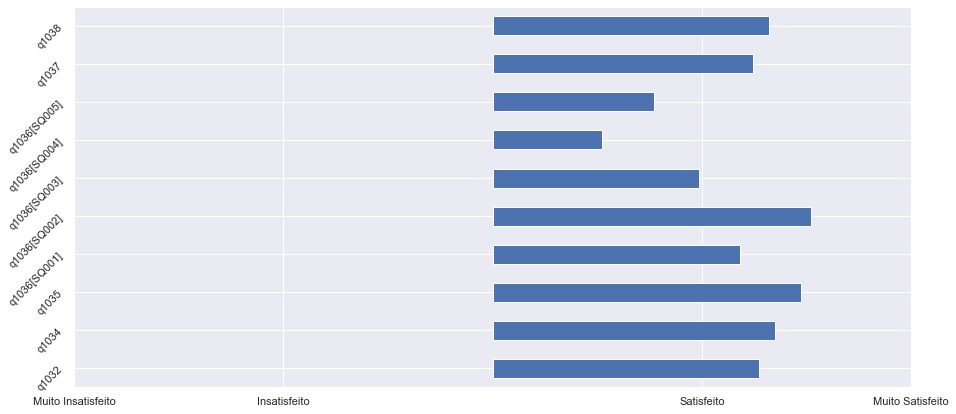

In [134]:
ax = (df_questoes_setic.describe().loc['mean'] - 2).plot.barh(figsize=(15, 7), rot=45)

#    .rename(index={
#        'q1032': '1032. Comunicação do PRODERJ',
#        'q1034': '1034. Auxílio e Orientação do PRODERJ',
#        'q1035': '1035. Indução de boas práticas do PRODERJ',
#        'q1036[SQ001]': '1036. Compreensibilidade dos normativos',
#        'q1036[SQ002]': '1036. Relevância dos temas dos normativos',
#        'q1036[SQ003]': '1036. Exequibilidade dos normativos',
#        'q1036[SQ004]': '1036. Temas urgentes pendentes',
#        'q1036[SQ005]': '1036. Prontidão para atendimento dos normativos',
#        'q1037': '1037. PRODERJ como integrador de soluções de TIC',
#        'q1038': '1038. Atendimento pelo PRODERJ supriu expectativas',
#    }) \
    
ax.set_xticks(ticks=[-2, -1, 1, 2], labels=['Muito Insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito Satisfeito'])
ax.set_xlim([-2, 2])

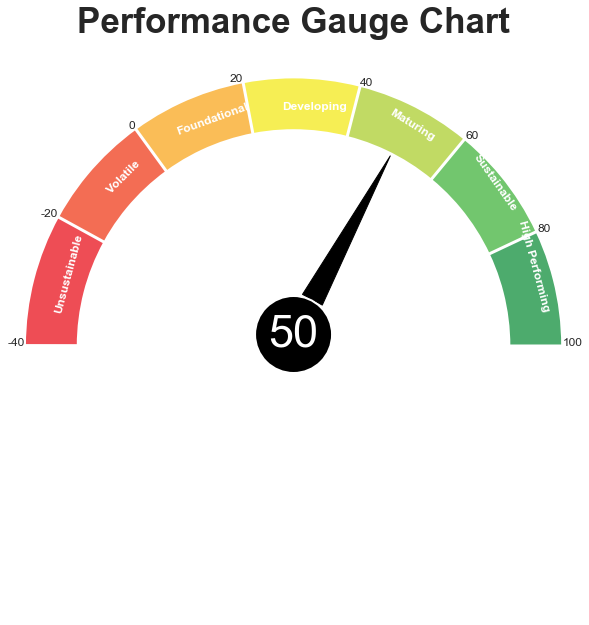

In [127]:
colors = ['#4dab6d', "#72c66e", "#c1da64", "#f6ee54", "#fabd57", "#f36d54", "#ee4d55"]

values = [100, 80, 60, 40, 20, 0, -20, -40]

x_axis_vals = [0, 0.44, 0.88,1.32,1.76,2.2,2.64]

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(projection="polar");

ax.bar(x=[0, 0.44, 0.88,1.32,1.76,2.2,2.64], width=0.5, height=0.5, bottom=2,
       linewidth=3, edgecolor="white",
       color=colors, align="edge");

plt.annotate("High Performing", xy=(0.16,2.1), rotation=-75, color="white", fontweight="bold");
plt.annotate("Sustainable", xy=(0.65,2.08), rotation=-55, color="white", fontweight="bold");
plt.annotate("Maturing", xy=(1.14,2.1), rotation=-32, color="white", fontweight="bold");
plt.annotate("Developing", xy=(1.62,2.2), color="white", fontweight="bold");
plt.annotate("Foundational", xy=(2.08,2.25), rotation=20, color="white", fontweight="bold");
plt.annotate("Volatile", xy=(2.46,2.25), rotation=45, color="white", fontweight="bold");
plt.annotate("Unsustainable", xy=(3.0,2.25), rotation=75, color="white", fontweight="bold");

for loc, val in zip([0, 0.44, 0.88,1.32,1.76,2.2,2.64, 3.14], values):
    plt.annotate(val, xy=(loc, 2.5), ha="right" if val<=20 else "left");

plt.annotate("50", xytext=(0,0), xy=(1.1, 2.0),
             arrowprops=dict(arrowstyle="wedge, tail_width=0.5", color="black", shrinkA=0),
             bbox=dict(boxstyle="circle", facecolor="black", linewidth=2.0, ),
             fontsize=45, color="white", ha="center"
            );


plt.title("Performance Gauge Chart", loc="center", pad=20, fontsize=35, fontweight="bold");

ax.set_axis_off();


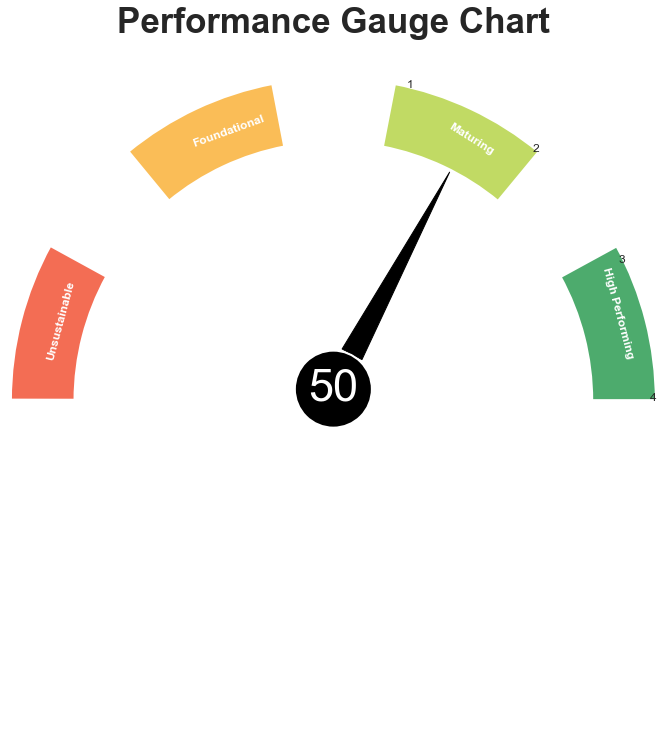

In [125]:
colors = ['#4dab6d',"#c1da64", "#fabd57", "#f36d54"]

values = [4, 3, 2, 1]

x_axis_vals = [0, 0.88, 1.76, 2.64] #[0, 0.44, 0.88, 1.32]
#[0, 0.44, 0.88,1.32,1.76,2.2,2.64]
fig = plt.figure(figsize=(12, 12))

ax = fig.add_subplot(projection="polar")

ax.bar(x=x_axis_vals, width=.5, height=0.5, bottom=2, linewidth=3, edgecolor="white", color=colors, align="edge")

plt.annotate("High Performing", xy=(0.16,2.1), rotation=-75, color="white", fontweight="bold");
plt.annotate("Sustainable", xy=(0.65,2.08), rotation=-55, color="white", fontweight="bold");
plt.annotate("Maturing", xy=(1.14,2.1), rotation=-32, color="white", fontweight="bold");
plt.annotate("Developing", xy=(1.62,2.2), color="white", fontweight="bold");
plt.annotate("Foundational", xy=(2.08,2.25), rotation=20, color="white", fontweight="bold");
plt.annotate("Volatile", xy=(2.46,2.25), rotation=45, color="white", fontweight="bold");
plt.annotate("Unsustainable", xy=(3.0,2.25), rotation=75, color="white", fontweight="bold");

for loc, val in zip([0, 0.44, 0.88,1.32,1.76,2.2,2.64, 3.14], values):
    plt.annotate(val, xy=(loc, 2.5), ha="right" if val<=20 else "left");

plt.annotate("50", xytext=(0,0), xy=(1.1, 2.0),
             arrowprops=dict(arrowstyle="wedge, tail_width=0.5", color="black", shrinkA=0),
             bbox=dict(boxstyle="circle", facecolor="black", linewidth=2.0, ),
             fontsize=45, color="white", ha="center"
            );


plt.title("Performance Gauge Chart", loc="center", pad=20, fontsize=35, fontweight="bold");

ax.set_axis_off();


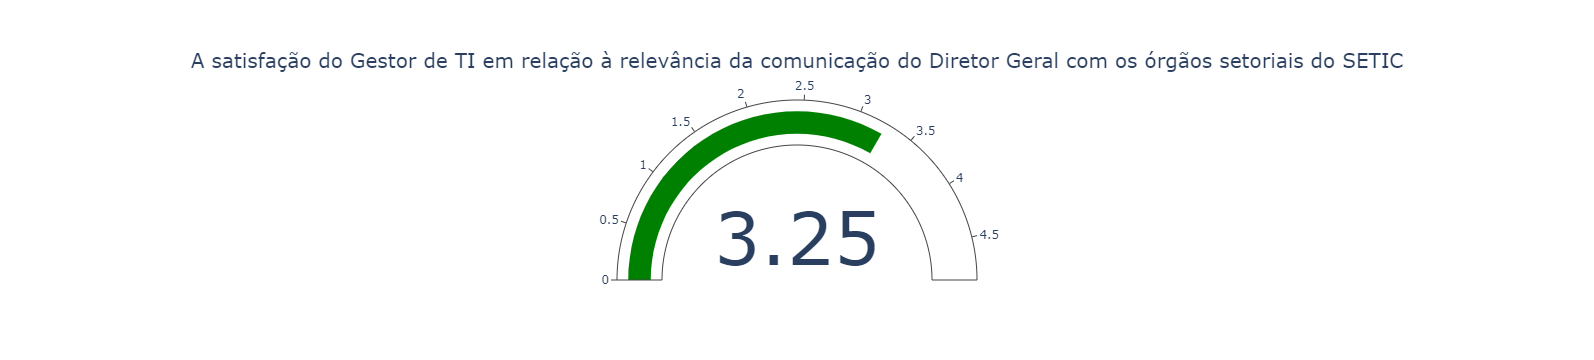

In [130]:
import plotly.graph_objects as go

layout = go.Layout(
    grid = {'rows': 1, 'columns': 2, 'pattern': 'independent'},
    width = 600,  # Width in pixels
    height = 300  # Height in pixels
)

fig = go.Figure(layout=layout)

# First value
fig.add_trace(go.Indicator(
    mode = "number+gauge",
    value = 3.25,
    
    title = {"text": "A satisfação do Gestor de TI em relação à relevância da comunicação do Diretor Geral com os órgãos setoriais do SETIC"},
    domain = {'x': [0, 1], 'y': [0, 1]}
))

fig.show()


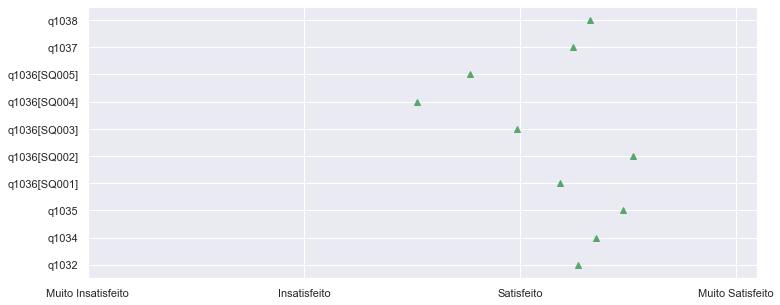

In [77]:
ax = df_questoes_setic.plot.box(showmeans=True, vert=False, showcaps=False, showbox=False, showfliers=False, whis=0, medianprops=dict(linewidth=.001), figsize=(12, 5))
ax.set_xticks(ticks=[1,2,3,4], labels=['Muito Insatisfeito', 'Insatisfeito', 'Satisfeito', 'Muito Satisfeito'])

# Coeficiente Alpha de Cronbach do Questionário

In [9]:

combinations = []

for r in range(len(df_questoes_setic.columns)+1):
    print(r)
    for combination in itertools.combinations(df_questoes_setic.columns, r):
        if len(combination) > 1:
            combinations.append(combination)
            alpha = pg.cronbach_alpha(data=df_questoes_setic[list(combination)])
            if alpha[0] > 0.8:                
                print(alpha, list(combination))            
            #pg.cronbach_alpha(data=df_cron)

print('Dado completo', pg.cronbach_alpha(data=df_questoes_setic))
df_questoes_setic.describe()

0
1
2
3
4
5
(0.800511295234708, array([0.718, 0.865])) ['q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037']
6
(0.8103212388598565, array([0.734, 0.871])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037']
(0.8104417488488457, array([0.734, 0.871])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1038']
(0.8087385472847649, array([0.732, 0.869])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ003]', 'q1037', 'q1038']
(0.8104649235323497, array([0.734, 0.871])) ['q1032', 'q1035', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037', 'q1038']
(0.814658468013214, array([0.74 , 0.873])) ['q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1037', 'q1038']
7
(0.8071306473744055, array([0.731, 0.868])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037']
(0.8049197955380557, array([0.728, 0.866])) ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1038']
(0.82935503546260

,q1032,q1034,q1035,q1036[SQ001],q1036[SQ002],q1036[SQ003],q1036[SQ004],q1036[SQ005],q1037,q1038
count,59.000000,54.000000,63.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,3.271186,2.962963,3.476190,3.184615,3.523077,2.984615,2.523077,2.769231,3.246154,3.323077
std,0.485319,0.867940,0.618457,0.496623,0.533494,0.649334,0.772732,0.655964,0.613157,0.562019
min,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,4.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


# Análise das perguntas sobre o SETIC no Questionário

Por meio dos dados acima é possível notar que o coeficiente alpha de cronbach maximiza-se quando é feito o processo de purificação, ou eliminação de questões, no processo da análise. 

O resultado é maior com 8 das 10 perguntas propostas, sendo excluídos os itens q1034 e q1036[SQ004].

Com as 10 questões inicialmente propostas atinge-se um valor alpha de 0.681774402337013, num intervalo de confiança de 0.561 a 0.78. O que apresenta um nível moderado de confiança no questionário.

Com o processo de purificação os dados são alpha de 0.8264530712262909, [0.759, 0.881]. O que apresenta um *nível alto* de confiança

### Teste de esferecidade da amostra de Bartlett

In [15]:
chi_square_value,p_value=calculate_bartlett_sphericity(df_questoes_setic.dropna())
chi_square_value, p_value

(132.382377988951, 1.5482856353143834e-10)

In [18]:
subconjunto = ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037', 'q1038']
chi_square_value,p_value=calculate_bartlett_sphericity(df_questoes_setic[subconjunto].dropna())
chi_square_value, p_value

(143.2502316870379, 1.9979396353757286e-17)

### Teste de esfericidade da amostra de Bartlett: 1.5482856353143834e-10, 

indicando que a amostra é adequada, pois avalia a significância geral de todas as correlações em uma matriz de correlação, sendo requeridos valores de p menores que 0,05. (TCU)

In this Bartlett ’s test, the p-value is 1.5482856353143834e-10. The test was statistically significant, indicating that the observed correlation matrix is not an identity matrix. https://www.datacamp.com/tutorial/introduction-factor-analysis



### Critério de Kaiser-Meyer-Olkin

In [17]:
kmo_all,kmo_model=calculate_kmo(df_questoes_setic.dropna())

kmo_all, kmo_model

(array([0.50611121, 0.38058306, 0.68727293, 0.61812999, 0.61320862,
        0.76195422, 0.40077306, 0.65477679, 0.65193173, 0.61751045]),
 0.6132385761540401)

In [19]:
subconjunto = ['q1032', 'q1035', 'q1036[SQ001]', 'q1036[SQ002]', 'q1036[SQ003]', 'q1036[SQ005]', 'q1037', 'q1038']
kmo_all,kmo_model=calculate_kmo(df_questoes_setic[subconjunto].dropna())

kmo_all, kmo_model

(array([0.68664001, 0.89127083, 0.86171081, 0.84903363, 0.77869437,
        0.80753759, 0.75487652, 0.76420558]),
 0.7932241002461508)